# **NETFLIX**

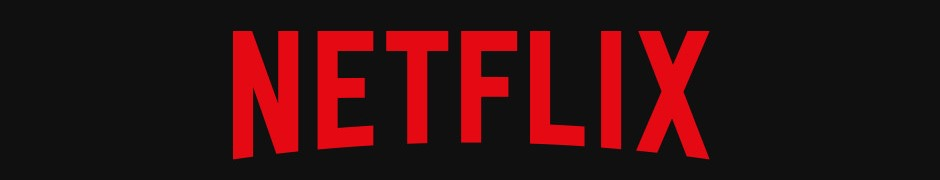

*Netflix is one of the most popular media and video streaming platforms. They
have over 8000 movies or tv shows available on their platform, as of mid-2021,
they have over 200M Subscribers globally. The particular business case focuses on the Netflix show data and provides insightful information on 8807 shows.*

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [118]:
data= pd.read_csv('Netflix_Dataset.csv')
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# **Problem Statement:**

*The primary objective of this analysis is to assist Netflix in making strategic decisions regarding the production of shows and movies, as well as expanding its business in various countries. We aim to provide data-driven recommendations to support the company in its decision-making process. By avoiding personal opinions or anecdotes and focusing solely on empirical evidence, we ensure that our recommendations are grounded in objective analysis. Additionally, we will present our findings in a clear and concise manner, avoiding technical jargon to facilitate understanding by business executives with basic knowledge of data science.*


# **Analysing Basic Metrics:**

1. Determine the variety of content available across different countries.

2. Investigate the trend in the number of movie releases per year over the past 20-30 years.

3. Explore the frequency of each categorical variable through both graphical and non-graphical analysis.

4. Contrast the quantity of TV shows and movies available on Netflix.

5. Identify the optimal timing for launching a movie or TV show.

6. Examine the involvement of actors and directors across various types of shows and movies.

7. Assess whether Netflix has shifted its focus towards TV shows compared to movies in recent years.

8. Analyze the diversity of content available in different countries.

9. Determine the popularity and production frequency of different genres of movies.

10. Calculate the duration between a movie's release and its addition to Netflix's platform.

# **Basic Analysis Of The Data - EDA**

**Getting Basic Info About The Dataset**

In [119]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


*>**Insight:** The dataset consists of 11 columns containing object datatype, while 1 column contains integer datatype*

**Shape Of Dataset**

In [120]:
data.shape

(8807, 12)

*>**Insight:** There are 8807 rows and 12 columns in the dataset*

**Statistical Summary**

In [121]:
data.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


*>**Insight:** This function calculates summary statistics, including count, mean, standard deviation, minimum, 25th percentile, median (50th percentile), 75th percentile, and maximum, for numerical columns within the DataFrame. These statistics aid in comprehending the central tendency, spread, and distribution of the data.*

In [122]:
data.describe(include= 'object').T

,count,unique,top,freq
show_id,8807,8807,s1,1
type,8807,2,Movie,6131
title,8807,8807,Dick Johnson Is Dead,1
director,6173,4528,Rajiv Chilaka,19
cast,7982,7692,David Attenborough,19
country,7976,748,United States,2818
date_added,8797,1767,"January 1, 2020",109
rating,8803,17,TV-MA,3207
duration,8804,220,1 Season,1793
listed_in,8807,514,"Dramas, International Movies",362


*>**Insight:** This command retrieves information about categorical data within the DataFrame, including the count of observations, the number of unique categories, the most frequent category, and its frequency for each categorical column.*

**Duplicate Values**

In [123]:
data.duplicated().any()

False

*>**Insight:** There are no duplicate rows in dataset.*

**Missing Values**

In [124]:
data.isna().any()

show_id         False
type            False
title           False
director         True
cast             True
country          True
date_added       True
release_year    False
rating           True
duration         True
listed_in       False
description     False
dtype: bool

In [125]:
data.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

*>**Insight:** The 'director' column contains 2634 null values, the 'cast' column has 825 null values, the 'country' column has 831 null values, the 'date_added' column has 10 null values, the 'rating' column has 4 null values, and the 'duration' column has 3 null values.*

**Dealing With Missing Values**

Handling null values

a. For categorical variables with null values, update those rows as
unknown_column_name.
Example : Replace missing value with Unknown Actor for missing value in
Actors column.

b. Replace with 0 for continuous variables having null values or mean of the column

In [126]:
data['director'].fillna('unknown_director', inplace= True)
data['cast'].fillna('unknown_cast', inplace= True)
data['country'].fillna('unknown_country', inplace= True)
data['rating'].fillna('unknown_rating', inplace= True)
data['date_added'].fillna('unknown_date', inplace= True)

In [127]:
data['duration_value']= data['duration'].str.split(' ').str[0].astype(float)
data['duration'].str.split(' ').str[0].astype(float)
data.loc[(data['type'] == 'Movie') & (data['duration_value'].isnull()), 'duration_value'] = data[data['type'] == 'Movie']['duration_value'].mean()

In [128]:
data['duration'].fillna('unknown_duration', inplace= True)

*For duration missing values we are creating a new column "duration_value" to keep only the numerical part and have replace the missing values of movie type with avg movie time. There are no missing value for TV Shows. We will be using the 'duration_vauel' column for any numerical analysis, and duration missing values are replaced by unknow_duration for categorical analysis*

In [129]:
data.isna().sum()

show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added        0
release_year      0
rating            0
duration          0
listed_in         0
description       0
duration_value    0
dtype: int64

*All Missing Values are handled*

**Conveting Datatypes**

In [130]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   show_id         8807 non-null   object 
 1   type            8807 non-null   object 
 2   title           8807 non-null   object 
 3   director        8807 non-null   object 
 4   cast            8807 non-null   object 
 5   country         8807 non-null   object 
 6   date_added      8807 non-null   object 
 7   release_year    8807 non-null   int64  
 8   rating          8807 non-null   object 
 9   duration        8807 non-null   object 
 10  listed_in       8807 non-null   object 
 11  description     8807 non-null   object 
 12  duration_value  8807 non-null   float64
dtypes: float64(1), int64(1), object(11)
memory usage: 894.6+ KB


*Conveting date_added coloums to datetime datatype*

*Converting type, rating, listed_in coloums to category datatype*

In [131]:
data['date_added']= pd.to_datetime(data['date_added'], errors= 'coerce')
data['type']= data['type'].astype('category')
data['rating']= data['rating'].astype('category')
data['listed_in']= data['listed_in'].astype('category')

In [132]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   show_id         8807 non-null   object        
 1   type            8807 non-null   category      
 2   title           8807 non-null   object        
 3   director        8807 non-null   object        
 4   cast            8807 non-null   object        
 5   country         8807 non-null   object        
 6   date_added      8797 non-null   datetime64[ns]
 7   release_year    8807 non-null   int64         
 8   rating          8807 non-null   category      
 9   duration        8807 non-null   object        
 10  listed_in       8807 non-null   category      
 11  description     8807 non-null   object        
 12  duration_value  8807 non-null   float64       
dtypes: category(3), datetime64[ns](1), float64(1), int64(1), object(7)
memory usage: 743.6+ KB


*Note that conveting release_year to datetime datatype will be done later in analysis.*

**Un-Nesting The Dataset**

*Un-nest the columns those have cells with multiple comma separated values by
creating multiple rows.*

In [133]:
data_unnested= data.copy()

In [134]:
np.shares_memory(data_unnested, data)

False

**Un-nesting The "Director" Column**

In [135]:
data_unnested['director']= data_unnested['director'].str.split(', ')
data_unnested= data_unnested.explode('director')

**Un-nesting The "Cast" Column**

In [136]:
data_unnested['cast']= data_unnested['cast'].str.split(', ')
data_unnested= data_unnested.explode('cast')

**Un-nesting The "Country" Column**

In [137]:
data_unnested['country']= data_unnested['country'].str.split(', ')
data_unnested= data_unnested.explode('country')

**Un-nesting The "Listed_in" Column**

In [138]:
data_unnested['listed_in']= data_unnested['listed_in'].str.split(', ')
data_unnested= data_unnested.explode('listed_in')

In [139]:
data_unnested.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown_cast,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0
1,s2,TV Show,Blood & Water,unknown_director,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2.0
1,s2,TV Show,Blood & Water,unknown_director,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",2.0
1,s2,TV Show,Blood & Water,unknown_director,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t...",2.0
1,s2,TV Show,Blood & Water,unknown_director,Khosi Ngema,South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2.0
1,s2,TV Show,Blood & Water,unknown_director,Khosi Ngema,South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",2.0
1,s2,TV Show,Blood & Water,unknown_director,Khosi Ngema,South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t...",2.0
1,s2,TV Show,Blood & Water,unknown_director,Gail Mabalane,South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2.0
1,s2,TV Show,Blood & Water,unknown_director,Gail Mabalane,South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",2.0
1,s2,TV Show,Blood & Water,unknown_director,Gail Mabalane,South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t...",2.0


*Note that we will use 'data' or 'data_unnested' dataframes depending on the analysis accordingly*

# **Basic Analysis**

**Top 10 Popular Directors**

In [140]:
data_unnested.groupby('director')['show_id'].nunique().sort_values(ascending= False).head(10)

director
unknown_director       2634
Rajiv Chilaka            22
Jan Suter                21
Raúl Campos              19
Suhas Kadav              16
Marcus Raboy             16
Jay Karas                15
Cathy Garcia-Molina      13
Martin Scorsese          12
Youssef Chahine          12
Name: show_id, dtype: int64

**Excluding Unknown_director**

In [141]:
data_unnested.loc[data_unnested['director'] != 'unknown_director'].groupby('director')['show_id'].nunique().sort_values(ascending= False).head(10)

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Jay Chapman            12
Martin Scorsese        12
Name: show_id, dtype: int64

*>**Insight:** It is observed that 'Rajiv Chilaka' is the most popular director on our platform, having directed 22 projects overall.*

**Top 10 Popular Artists**

In [142]:
data_unnested.groupby('cast')['show_id'].nunique().sort_values(ascending= False).head(10)

cast
unknown_cast        825
Anupam Kher          43
Shah Rukh Khan       35
Julie Tejwani        33
Naseeruddin Shah     32
Takahiro Sakurai     32
Rupa Bhimani         31
Om Puri              30
Akshay Kumar         30
Yuki Kaji            29
Name: show_id, dtype: int64

**Excluding Unknown_cast**

In [143]:
data_unnested.loc[data_unnested['cast'] != 'unknown_cast'].groupby('cast')['show_id'].nunique().sort_values(ascending= False).head(10)

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Amitabh Bachchan    28
Name: show_id, dtype: int64

*>**Insight:** It is evident that 'Anupam Kher' is the most popular artist on our platform, having acted in 43 projects overall.*

**Top 10 Content Consuming Countries**

In [144]:
data_unnested.groupby('country')['show_id'].nunique().sort_values(ascending= False).head(10)

country
United States      3689
India              1046
unknown_country     831
United Kingdom      804
Canada              445
France              393
Japan               318
Spain               232
South Korea         231
Germany             226
Name: show_id, dtype: int64

**Excluding Unknown_country**

In [145]:
data_unnested[data_unnested['country'] != 'unknown_country'].groupby('country')['show_id'].nunique().sort_values(ascending= False).head(10)

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: show_id, dtype: int64

*>**Insight:** It is evident that the United States is the top consumer of our content, with a total of 3689 content titles watched.*

**Top 10 Release Years**

In [146]:
data_unnested.groupby('release_year')['show_id'].nunique().sort_values(ascending= False).head(10)

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: show_id, dtype: int64

*>**Insight:** It is evident that '2018' is the most common release year for content, with 1147 content titles having this release year.*

**Top 10 Ratings**

In [147]:
data_unnested.groupby('rating')['show_id'].nunique().sort_values(ascending= False).head(10)

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: show_id, dtype: int64

*>**Insight:** It is evident that 'TV-MA' is the most common rating for content on our platform, with 3207 content titles having this rating overall.*

**Top 10 Duration of Content**

In [148]:
data_unnested[data_unnested['duration'] != 'unknown_duration'].groupby('duration')['show_id'].nunique().sort_values(ascending= False).head(10)

duration
1 Season     1793
2 Seasons     425
3 Seasons     199
90 min        152
97 min        146
93 min        146
94 min        146
91 min        144
95 min        137
96 min        130
Name: show_id, dtype: int64

*>**Insight:** It is evident that '1 season in TV Shows' is the most common type of content on our platform, with 1793 content titles overall.*

**Top 10 Popular Genres**

In [149]:
data_unnested.groupby('listed_in')['show_id'].nunique().sort_values(ascending= False).head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: show_id, dtype: int64

*>**Insight:** It is evident that 'International Movies' is the most popular genre on our platform, with a total of 2752 movies of this genre represented.*

# **1. Analysing Each Categorical Variable Both Using Graphical And Non-graphical Analysis**

Find the counts of each categorical variable both using graphical and nongraphical analysis.

a. For Non-graphical Analysis:
Hint : We want you to find the values counts of each category for the given
column

b. For graphical analysis:
Hint : We can use a count plot to get the counts of each category

**Analysing "Type" Categorical Variable**

**Non-graphical Analysis- Type**

In [150]:
data['type'].value_counts()

Movie      6131
TV Show    2676
Name: type, dtype: int64

**Graphical Analysis- Type**

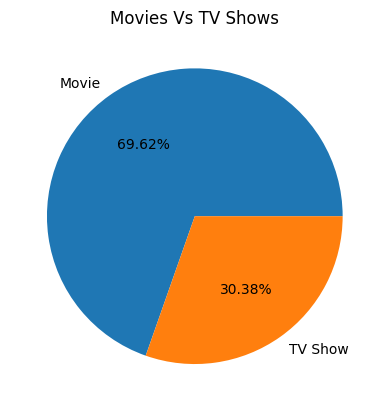

In [151]:
value= data['type'].value_counts()
type_data= data['type'].value_counts().index
plt.pie([6131, 2676], labels= type_data, autopct= '%2.2f%%')
plt.title('Movies Vs TV Shows')
plt.show()

**Insight And Recommendation**

*>**Insight:** It is evident that movies constitute 69.62% of the content on our platform, while TV shows make up 30.38%. Therefore, movies dominate the content type on our platform.*


*>**Recommendation:** Considering that movies comprise the majority of content on our platform, we should continue to prioritize the acquisition and production of high-quality movies. Additionally, while TV shows constitute a smaller portion, we should still invest in developing compelling TV show content to cater to the diverse preferences of our audience. By maintaining a strong focus on both movies and TV shows, we can effectively engage our subscribers and enhance their viewing experience.*

**Analysing "Director" Column**

**Non-graphical Analysis- Director**


In [152]:
data_unnested.loc[data_unnested['director'] != 'unknown_director'].groupby('director')['show_id'].nunique().sort_values(ascending= False).head(10)

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Jay Chapman            12
Martin Scorsese        12
Name: show_id, dtype: int64

**Graphical Analysis- Director**

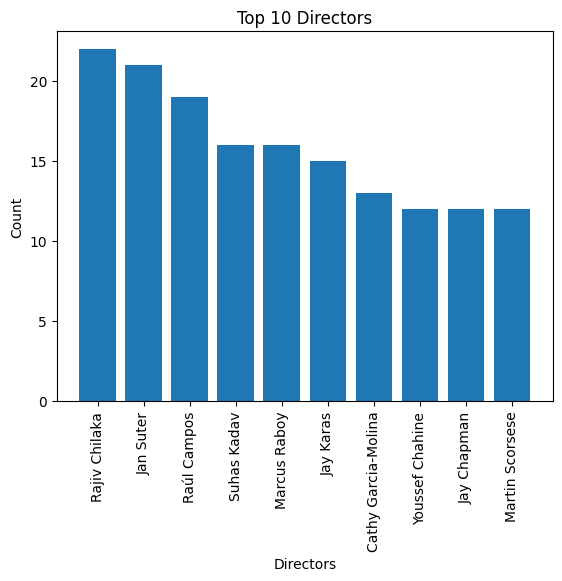

In [153]:
x= data_unnested.loc[data_unnested['director'] != 'unknown_director'].groupby('director')['show_id'].nunique().sort_values(ascending= False).head(10).index
y= data_unnested.loc[data_unnested['director'] != 'unknown_director'].groupby('director')['show_id'].nunique().sort_values(ascending= False).head(10)
plt.bar(x, y)
plt.xticks(rotation= 90)
plt.xlabel('Directors')
plt.ylabel('Count')
plt.title('Top 10 Directors')
plt.show()

**Insight And Recommendation**

*>**Insight:** Above are the top 10 director and it is observed that 'Rajiv Chilaka' is the most popular director on our platform, having directed 22 movies.*

*>**Recommendation:** Given that 'Rajiv Chilaka' stands out as the most popular director on our platform, having directed 22 movies, we should consider collaborating with him further to leverage his proven track record in creating successful content. Exploring additional projects with 'Rajiv Chilaka' could potentially attract more viewers and contribute to the platform's growth. Additionally, identifying and nurturing relationships with other top directors could also enhance our content library and broaden our audience appeal.*

**Analysing "Cast" Column**

**Non-Graphical Analysis- Cast**

In [154]:
data_unnested.loc[data_unnested['cast'] != 'unknown_cast'].groupby('cast')['show_id'].nunique().sort_values(ascending= False).head(10)

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Amitabh Bachchan    28
Name: show_id, dtype: int64

**Graphical Analysis- Cast**

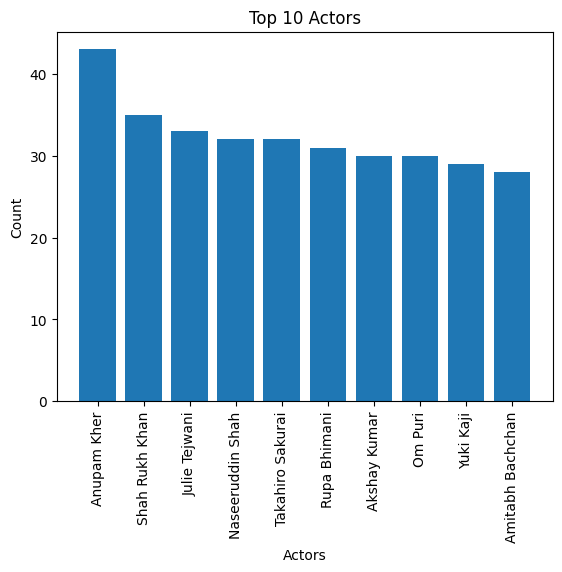

In [155]:
x= data_unnested.loc[data_unnested['cast'] != 'unknown_cast'].groupby('cast')['show_id'].nunique().sort_values(ascending= False).head(10).index
y= data_unnested.loc[data_unnested['cast'] != 'unknown_cast'].groupby('cast')['show_id'].nunique().sort_values(ascending= False).head(10)
plt.bar(x, y)
plt.xticks(rotation= 90)
plt.xlabel('Actors')
plt.ylabel('Count')
plt.title('Top 10 Actors')
plt.show()

**Insight And Recommendation**

*>**Insight:** Above are the top 10 director and it is evident that 'Anupam Kher' is the most popular artist on our platform, having acted in 43 movies.*

*>**Recommendation:** Considering that 'Anupam Kher' emerges as the most popular artist on our platform, having acted in 43 movies, we should explore further collaborations with him to capitalize on his widespread popularity among our audience. By leveraging 'Anupam Kher's talent and appeal, we can potentially attract more viewers and enhance engagement on our platform. Additionally, we should continue to seek opportunities to feature 'Anupam Kher' in a diverse range of projects to cater to different audience preferences and ensure sustained interest in our content offering.*

**Analysing "Rating" Categorical Variable**

**Non-graphical Analysis- Rating**

In [156]:
data['rating'].value_counts().head(10)

TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: rating, dtype: int64

**Graphical Analysis- Rating**

<ipython-input-157-b06fe485cf94>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= data, x= 'rating', order= data['rating'].value_counts().head(10).index, palette= "Set2")


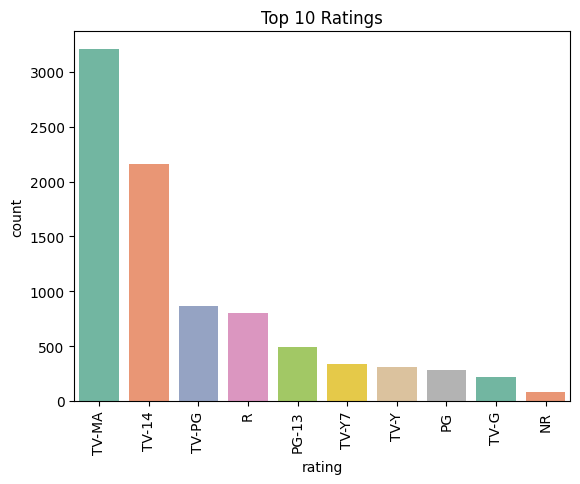

In [157]:
sns.countplot(data= data, x= 'rating', order= data['rating'].value_counts().head(10).index, palette= "Set2")
plt.xticks(rotation= 90)
plt.title('Top 10 Ratings')
plt.show()

**Insight And Recommendation**

*>**Insight:** Above are the top 10 director and it is evident that 'TV-MA' is the most common rating for content on our platform, with 3207 content titles having this rating.*

*>**Recommendation:** With 'TV-MA' emerging as the most common rating for content on our platform, appearing in 3207 titles, it is essential to maintain a diverse range of content that aligns with this rating. Given the popularity of 'TV-MA' content, we should continue to invest in producing and acquiring content that caters to this audience segment. Additionally, while prioritizing 'TV-MA' content, we should also ensure a balanced content offering that appeals to viewers across various age groups and preferences. By catering to the preferences of 'TV-MA' viewers while also offering diverse content options, we can effectively engage a wider audience and enhance overall viewer satisfaction on our platform.*

**Analysing "Genre" Categorical Variable**

**Non-graphical Analysis- Listed_in**

In [158]:
data_unnested.groupby('listed_in')['show_id'].nunique().sort_values(ascending= False).head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: show_id, dtype: int64

**Graphical Analysis- Listed_in**

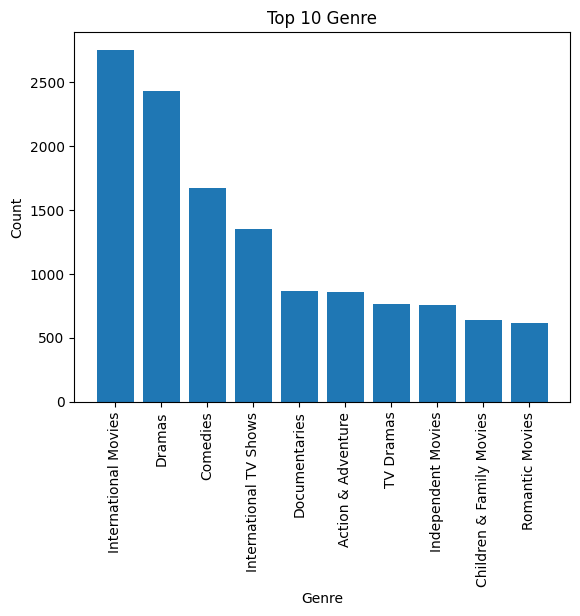

In [159]:
x= data_unnested.groupby('listed_in')['show_id'].nunique().sort_values(ascending= False).head(10).index
y= data_unnested.groupby('listed_in')['show_id'].nunique().sort_values(ascending= False).head(10)
plt.bar(x, y)
plt.xticks(rotation= 90)
plt.xlabel('Genre')
plt.ylabel('Count')
plt.title('Top 10 Genre')
plt.show()

**Insight And Recommendation**

*>**Insight:** Above are the top 10 Genre and it is evident that 'International Movies' is the most popular genre on our platform, with a total of 2752 movies of this genre represented.*

*>**Recommendation:** Given that 'International Movies' emerges as the most popular genre on our platform, represented by a total of 2752 movies, we should continue to prioritize acquiring and producing content within this genre to cater to the preferences of our audience. Additionally, we should explore opportunities to diversify our content library by featuring content from a wide range of countries and cultures, further enhancing the international appeal of our platform. By investing in 'International Movies' and offering a rich and varied selection within this genre, we can effectively engage viewers from diverse backgrounds and strengthen our position as a global streaming platform.*

**Analysing "Release_year" Column**

**Non-Graphical Analysis- Release_year**

In [160]:
data['release_year'].value_counts().head(10)

2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: release_year, dtype: int64

**Graphical Analysis- Release_year**

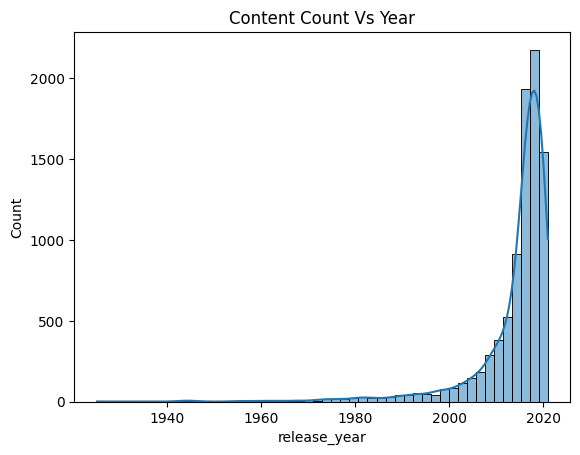

In [161]:
data['release_year'].value_counts().head(10)
sns.histplot(data= data['release_year'], bins= 50, kde= True)
plt.title('Content Count Vs Year')
plt.show()

**Insight And Recommendation**

*>**Insight:** It is evident that '2018' is the most common release year for content on our platform.*


*>**Recommendation:** Since '2018' emerges as the most common release year for content on our platform, it suggests that viewers have a significant interest in recent releases. To capitalize on this trend, we should prioritize acquiring and producing content from recent years, focusing particularly on titles released in '2018' and onwards. Additionally, while maintaining a strong focus on recent releases, we should also ensure a diverse content library that includes classics and older titles to cater to a wide range of viewer preferences. By offering a balanced mix of recent and older content, we can effectively engage our audience and provide them with a compelling viewing experience.*

# **2. Comparison Of TV Shows Vs. Movies**

a. Find the number of movies produced in each country and pick the top 10
countries.
Hint : We want you to apply group by each country and find the count of unique
titles/id of movies

b. Find the number of Tv-Shows produced in each country and pick the top 10
countries.
Hint : We want you to apply group by each country and find the count of unique
titles/id of Tv-shows

**Top 10 Countries For Movies**

In [162]:
data_unnested[(data_unnested['type'] == 'Movie') & (data_unnested['country'] != 'unknown_country')].groupby('country')['show_id'].nunique().sort_values(ascending= False).head(10)

country
United States     2751
India              962
United Kingdom     532
Canada             319
France             303
Germany            182
Spain              171
Japan              119
China              114
Mexico             111
Name: show_id, dtype: int64

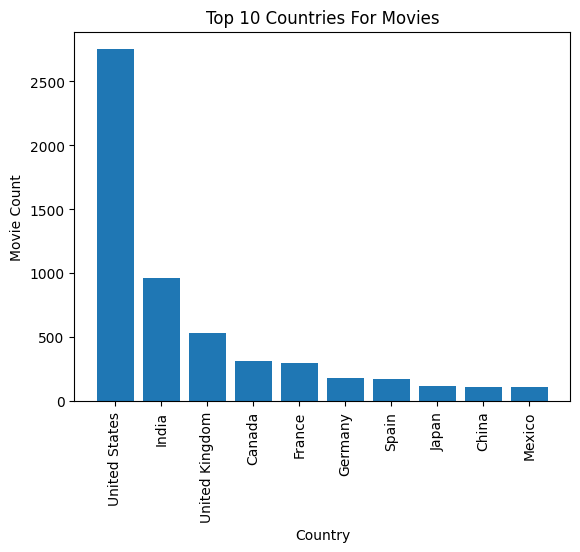

In [163]:
x= data_unnested[(data_unnested['type'] == 'Movie') & (data_unnested['country'] != 'unknown_country')].groupby('country')['show_id'].nunique().sort_values(ascending= False).head(10).index
y= data_unnested[(data_unnested['type'] == 'Movie') & (data_unnested['country'] != 'unknown_country')].groupby('country')['show_id'].nunique().sort_values(ascending= False).head(10)
plt.bar(x, y)
plt.xticks(rotation= 90)
plt.xlabel('Country')
plt.ylabel('Movie Count')
plt.title('Top 10 Countries For Movies')
plt.show()

**Insight And Recommendation**

*>**Insight:** The top 10 countries where movies are most popular are listed above, with the United States being the top country, having 2751 movies.*

*>**Recommendation:** Given that the United States emerges as the top country where movies are most popular on our platform, with 2751 titles, we should continue to prioritize acquiring and producing content that resonates with American audiences. Additionally, we should explore opportunities to expand our content offerings in other top-performing countries to further diversify our audience base and strengthen our global presence. By tailoring our content strategy to cater to the preferences of viewers in the United States and other key markets, we can effectively engage audiences worldwide and drive growth for our platform.*

**Top 10 Countries For TV Show**

In [164]:
data_unnested[(data_unnested['type'] == 'TV Show') & (data_unnested['country'] != 'unknown_country')].groupby('country')['show_id'].nunique().sort_values(ascending= False).head(10)

country
United States     938
United Kingdom    272
Japan             199
South Korea       170
Canada            126
France             90
India              84
Taiwan             70
Australia          66
Spain              61
Name: show_id, dtype: int64

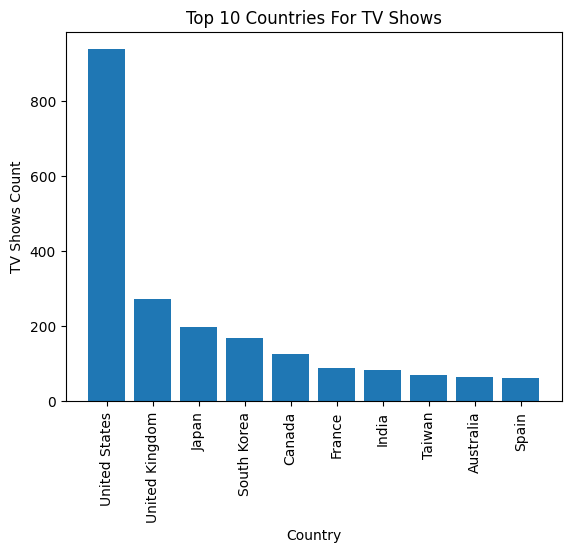

In [165]:
x= data_unnested[(data_unnested['type'] == 'TV Show') & (data_unnested['country'] != 'unknown_country')].groupby('country')['show_id'].nunique().sort_values(ascending= False).head(10).index
y= data_unnested[(data_unnested['type'] == 'TV Show') & (data_unnested['country'] != 'unknown_country')].groupby('country')['show_id'].nunique().sort_values(ascending= False).head(10)
plt.bar(x, y)
plt.xticks(rotation= 90)
plt.xlabel('Country')
plt.ylabel('TV Shows Count')
plt.title('Top 10 Countries For TV Shows')
plt.show()

**Insight And Recommendation**

*>**Insight:** The top 10 countries where TV Shows are most popular are listed above, with the United States being the top country, having 938 movies.*

*>**Recommendation:** Considering the United States' significant viewership for TV shows, it's crucial to continue prioritizing content acquisition and production that resonates with American audiences. Additionally, we should explore strategies to further enhance our TV show offerings in other top-performing countries identified in the list. By tailoring our content strategy to meet the preferences of viewers in key markets like the United States and expanding our presence globally, we can effectively engage audiences across different regions and drive sustained growth for our platform.*

**Movies Vs TV SHows In Top 10 Content Consuming Contries Overall**

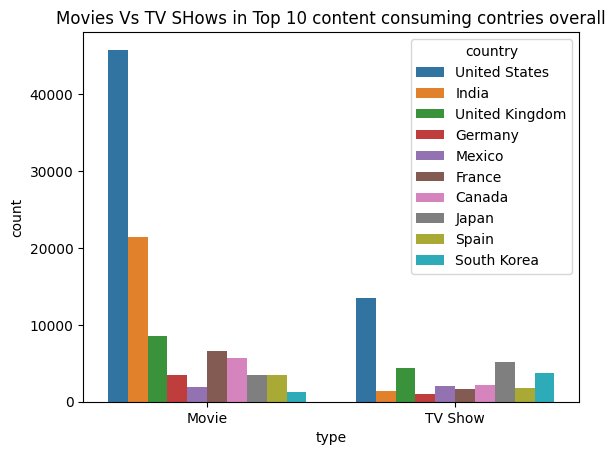

In [166]:
top10__country= data_unnested[data_unnested['country'] != 'unknown_country'].groupby('country')['show_id'].nunique().sort_values(ascending= False).head(10).index
type_count= data['type'].value_counts().index
top_country_content= data_unnested.loc[(data_unnested['country'].isin(top10__country)) & (data_unnested['type'].isin(type_count))]
sns.countplot(data= top_country_content, x= 'type', hue= 'country')
plt.title('Movies Vs TV SHows in Top 10 content consuming contries overall')
plt.show()

**Insight And Recommendation**

*>**Insight:** The above displays the distribution of Movies and tv shows for top 10 content consuming contries overall.*

*>**Recommendation:** Understanding the content consumption patterns in these top countries is crucial for our content strategy. We should analyze further to identify trends and preferences specific to each country, allowing us to tailor our content offerings accordingly. By aligning our content strategy with the preferences of audiences in these key markets, we can effectively engage viewers, enhance user satisfaction, and drive growth for our platform.*

**Top 10 Genre For Movies And TV Shows**

In [167]:
data_unnested[data_unnested['type'] == 'Movie'].groupby('listed_in')['show_id'].nunique().sort_values(ascending= False).head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
Documentaries                869
Action & Adventure           859
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
Music & Musicals             375
Name: show_id, dtype: int64

In [168]:
data_unnested[data_unnested['type'] == 'TV Show'].groupby('listed_in')['show_id'].nunique().sort_values(ascending= False).head(10)

listed_in
International TV Shows    1351
TV Dramas                  763
TV Comedies                581
Crime TV Shows             470
Kids' TV                   451
Docuseries                 395
Romantic TV Shows          370
Reality TV                 255
British TV Shows           253
Anime Series               176
Name: show_id, dtype: int64

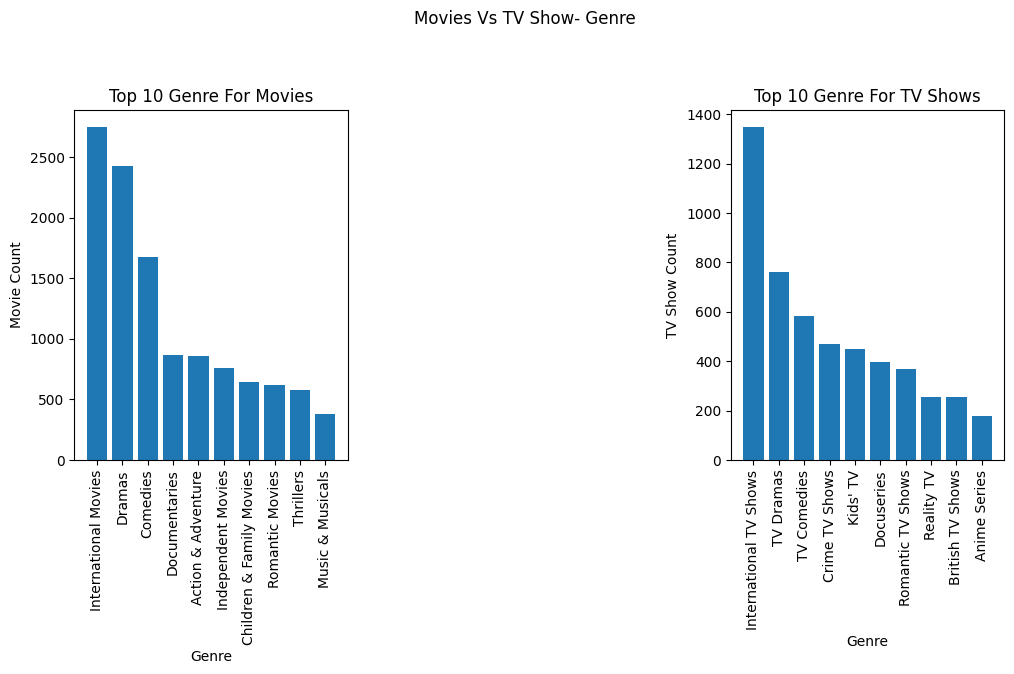

In [169]:
plt.figure(figsize= (12, 10))

plt.subplot(2,3,1)
x= data_unnested[data_unnested['type'] == 'Movie'].groupby('listed_in')['show_id'].nunique().sort_values(ascending= False).head(10).index
y= data_unnested[data_unnested['type'] == 'Movie'].groupby('listed_in')['show_id'].nunique().sort_values(ascending= False).head(10)
plt.bar(x, y)
plt.xticks(rotation= 90)
plt.xlabel('Genre')
plt.ylabel('Movie Count')
plt.title('Top 10 Genre For Movies')

plt.subplot(2,3,3)
a= data_unnested[data_unnested['type'] == 'TV Show'].groupby('listed_in')['show_id'].nunique().sort_values(ascending= False).head(10).index
b= data_unnested[data_unnested['type'] == 'TV Show'].groupby('listed_in')['show_id'].nunique().sort_values(ascending= False).head(10)
plt.bar(a, b)
plt.xticks(rotation= 90)
plt.xlabel('Genre')
plt.ylabel('TV Show Count')
plt.title('Top 10 Genre For TV Shows')

plt.suptitle('Movies Vs TV Show- Genre')
plt.show()

**Insight And Recommendation**


*>**Insight:** When combining the data for both movies and TV shows, we observe that 'International Content' holds significant popularity across both categories, with 'International Movies' being the most popular genre for movies and 'International TV Shows' dominating the TV show category. This indicates a global audience preference for diverse cultural content.
Additionally, 'Dramas' emerge as a popular genre in both movies and TV shows, suggesting a widespread interest in narrative-driven content among viewers.*

*>**Recommendation:** Given the popularity of 'International Content' and 'Dramas' across both movies and TV shows, we should prioritize acquiring and producing content within these genres. Furthermore, we should continue to diversify our library by featuring content from other popular genres such as 'Comedies,' 'Action & Adventure' for movies, and 'Crime TV Shows,' 'Kids' TV' for TV shows. By offering a well-rounded selection of content across various genres, we can cater to the diverse preferences of our audience and enhance engagement on our platform. Additionally, exploring opportunities for cross-platform collaborations and co-productions in popular genres could further expand our content offerings and attract a wider audience base.*

**Distribution Of Duration Of Movies And TV Shows**

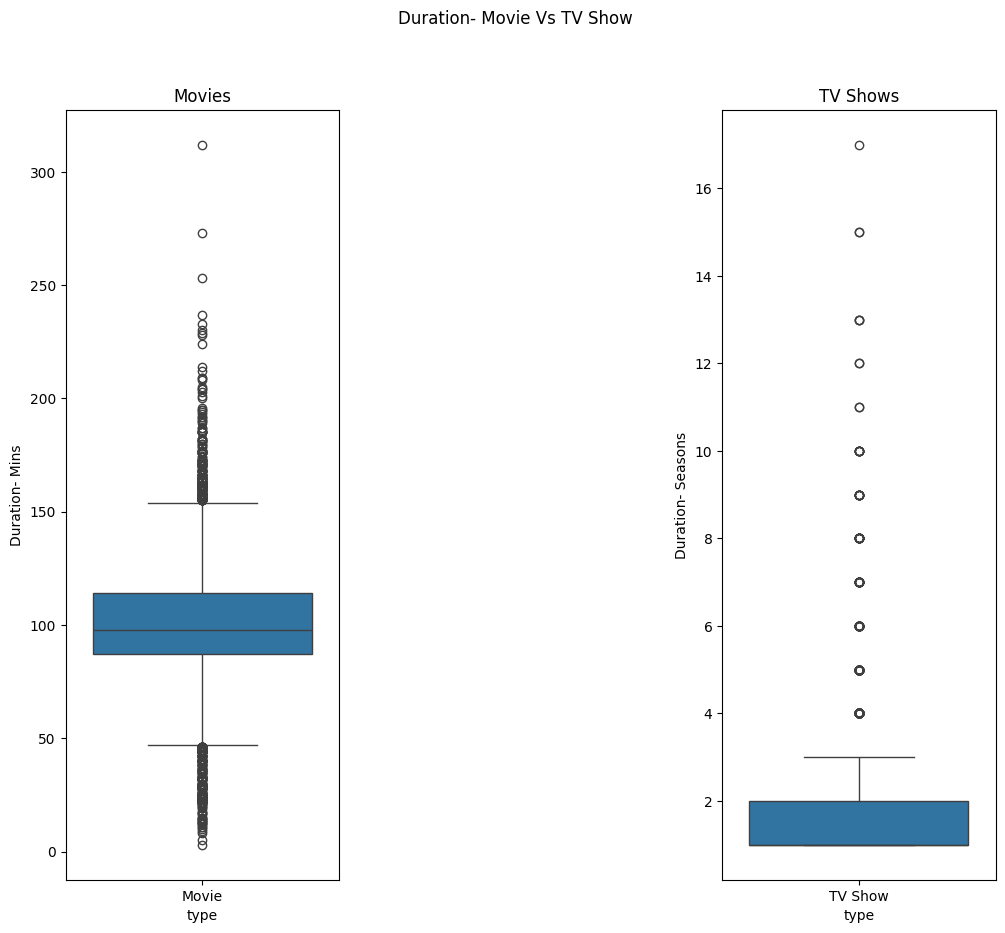

In [170]:
plt.figure(figsize= (12, 10))

plt.suptitle('Duration- Movie Vs TV Show')

plt.subplot(1,3,1)
sns.boxplot(data= data.loc[data['type'] == 'Movie'].astype('object'), x= 'type', y= 'duration_value')
plt.ylabel('Duration- Mins')
plt.title('Movies')

plt.subplot(1,3,3)
sns.boxplot(data= data.loc[data['type'] == 'TV Show'].astype('object'), x= 'type', y= 'duration_value')
plt.ylabel('Duration- Seasons')
plt.title('TV Shows')
plt.show()

**Insight And Recommendation**

*>**Insight:** Upon analyzing the duration of movies, we observe a wide range of durations, with the lower end typically around 50 minutes and the upper end around the 150-minute range. The median duration falls around 100 minutes, indicating that most movies on our platform have a runtime of approximately an hour and a half. However, there are numerous outliers both on the lower and upper ends of the spectrum, with some movies exceeding 300 minutes in length. This suggests a diverse range of movie lengths catering to varying viewer preferences and storytelling styles.*

*For TV shows, we find that the lower end of the duration spectrum typically consists of shows with 0 to 1 season, indicating very short series. On the upper end, we observe shows with up to 3 seasons, suggesting that most TV shows on our platform fall within this range. However, there are numerous outliers with some TV shows spanning up to 17 seasons, indicating long-running series with a dedicated fan base. This diversity in the duration of TV shows reflects the broad range of storytelling formats available to viewers, catering to both binge-watchers and those who prefer shorter, self-contained narratives.*

*>**Recommendation:** Diversify Movie Runtimes: Given the wide range of movie durations, it is essential to cater to different viewer preferences. While shorter movies offer quick entertainment options, longer films provide immersive storytelling experiences. Therefore, we should continue acquiring and producing movies with varying runtimes to appeal to a broader audience base.*

*Curate Short-form Content: Considering the popularity of short TV shows with 0 to 1 seasons, we should explore opportunities to curate and promote short-form series that offer concise and engaging storytelling. This could include anthology series, miniseries, or web series that provide high-quality content within a limited runtime, catering to viewers with limited time commitments.*

*Invest in Long-running Series: With the presence of long-running TV shows spanning multiple seasons, we should invest in acquiring and producing compelling series with the potential for longevity. Building a portfolio of successful long-running series can foster viewer loyalty and encourage sustained engagement on our platform. Additionally, we should analyze viewer metrics and audience feedback to identify genres and themes that resonate well with viewers, guiding our decisions in developing new long-running series.*

*Content Curation and Recommendation: Implementing robust content curation and recommendation algorithms can help users discover movies and TV shows tailored to their preferences and viewing habits. By leveraging user data and machine learning techniques, we can personalize recommendations, enhancing the overall viewing experience and driving user engagement.*

*Collaborate with Content Creators: To ensure a diverse and compelling content library, we should collaborate with content creators, filmmakers, and production studios worldwide. By fostering partnerships and co-productions, we can access a wide range of creative talent and cultural perspectives, enriching our content offerings and attracting a global audience.*

*Monitor Viewer Engagement: Continuously monitor viewer engagement metrics, including watch time, completion rates, and user feedback, to evaluate the performance of different types of content. This data-driven approach will enable us to identify trends, preferences, and emerging content formats, guiding our content acquisition and production strategies for optimal audience engagement and retention.*

**Release Year- Movie Vs TV Show**

In [171]:
data[data['type'] == 'Movie']['release_year'].value_counts().head(10)

2017    767
2018    767
2016    658
2019    633
2020    517
2015    398
2021    277
2014    264
2013    225
2012    173
Name: release_year, dtype: int64

In [172]:
data[data['type'] == 'TV Show']['release_year'].value_counts().head(10)

2020    436
2019    397
2018    380
2021    315
2017    265
2016    244
2015    162
2014     88
2012     64
2013     63
Name: release_year, dtype: int64

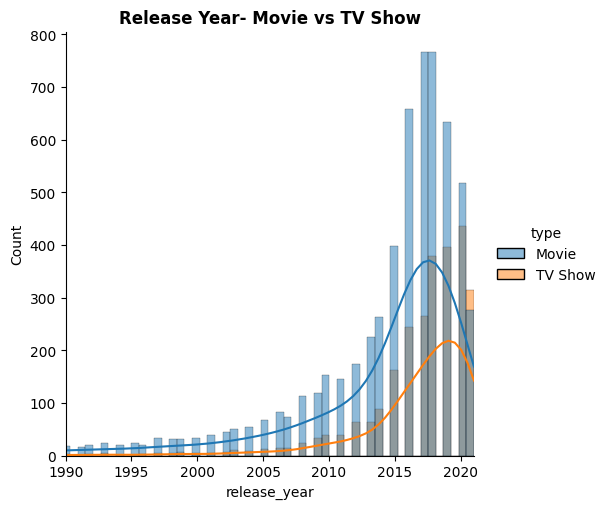

In [173]:
sns.displot(data, x= 'release_year', hue= 'type', kde= True)
plt.xlim(1990,2021)
plt.title("Release Year- Movie vs TV Show",fontsize=12,weight="bold")
plt.show()

**Insight**

*>**Insight:**Release Trends: The distribution of movie release years highlights fluctuations in annual production volumes, with certain years experiencing higher activity levels than others. Understanding these trends can inform Netflix's content acquisition and licensing strategies to ensure a diverse and up-to-date movie catalog.*

*Peak Years: 2017 and 2018 emerge as peak years for movie releases, with both years witnessing the highest number of movie additions to Netflix. This indicates a period of heightened production and acquisition activity, potentially driven by factors such as industry trends, blockbuster releases, and content partnerships.*

*Recent Trends: While 2017 and 2018 saw significant movie additions, subsequent years, such as 2019 and 2020, experienced a slight decline in the number of movie releases. However, it's noteworthy that 2020 still maintained a relatively high number of movie additions despite challenges posed by the global pandemic, indicating resilience and adaptability within the entertainment industry.*

*Content Diversity: Netflix should prioritize acquiring movies from a wide range of release years to offer subscribers a diverse selection of content spanning different genres, eras, and cultural backgrounds. By curating a varied movie catalog, Netflix can cater to the diverse tastes and preferences of its global audience.*

*Strategic Acquisitions: Netflix should leverage insights from release year trends to strategically acquire and license movies that align with emerging viewer preferences and market demands. By investing in high-quality and culturally relevant content from peak years, Netflix can enhance its competitive edge and retain subscriber engagement.*

**Top 10 Genre Overall- Movies Vs TV Show**


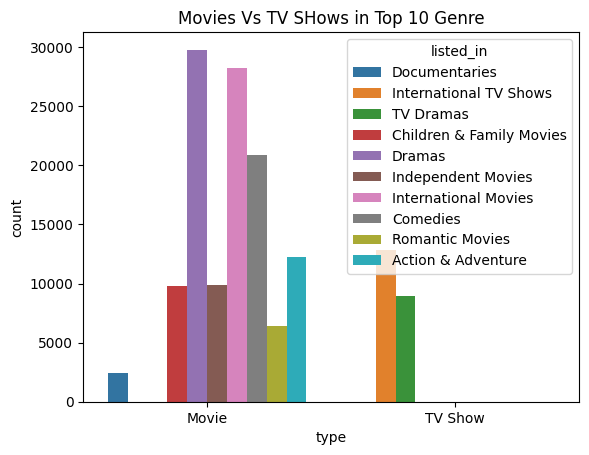

In [174]:
top10__genre= data_unnested.groupby('listed_in')['show_id'].nunique().sort_values(ascending= False).head(10).index
type_count= data['type'].value_counts().index
top_genre= data_unnested.loc[(data_unnested['listed_in'].isin(top10__genre)) & (data_unnested['type'].isin(type_count))]
sns.countplot(data= top_genre, x= 'type', hue= 'listed_in')
plt.title('Movies Vs TV SHows in Top 10 Genre')
plt.show()

**Insight And Recommendation**

*>**Insight:** Genre Preferences: The data reveals that dramas and international movies are the most prevalent genres among movies, while TV dramas and international TV shows dominate among TV shows. This indicates a strong audience interest in compelling narratives and diverse cultural experiences across both movie and TV show formats.*

*Global Appeal: The popularity of dramas and international content underscores their universal appeal, transcending geographical boundaries and resonating with audiences worldwide. This suggests that Netflix can capitalize on these genres to cater to its diverse global subscriber base, fostering inclusivity and cultural exchange.*

*Genre Diversity: While dramas and international content are prominent, it's crucial for Netflix to maintain a diverse range of genres to cater to varied viewer preferences. Offering a balanced mix of genres such as comedies, thrillers, documentaries, etc., ensures that Netflix's content library appeals to a broad spectrum of audiences, enhancing viewer satisfaction and engagement.*

*Content Curation: Netflix should continue investing in acquiring and producing high-quality content within popular genres like dramas and TV dramas. By leveraging insights from viewer preferences and market trends, Netflix can curate compelling content that captivates audiences and differentiates itself from competitors.*

*Strategic Acquisitions: Understanding the popularity of specific genres can inform Netflix's content acquisition strategy. By strategically acquiring rights to sought-after genres and collaborating with renowned creators and studios, Netflix can enhance its content offering and solidify its position as a leading streaming platform in the competitive entertainment industry.*

*>**Recommendation:** Diversify Content: While maintaining focus on popular genres, Netflix should also explore niche genres to cater to specialized audience interests and expand its content catalog.*

*Invest in Originals: Developing original content across various genres allows Netflix to differentiate itself and retain subscribers. Investing in original productions can also provide creative freedom and exclusive content unavailable elsewhere.*

*Personalization: Utilize data analytics and recommendation algorithms to personalize content recommendations for individual viewers based on their viewing history, preferences, and demographic information.*

*Global Expansion: Continuously assess and adapt content strategies to cater to diverse international markets. Investing in local content production and licensing agreements can strengthen Netflix's presence in global markets.*

*Engage with Creators: Foster relationships with talented creators, directors, and production studios to collaborate on innovative projects. Supporting diverse voices and storytelling perspectives can lead to fresh and compelling content offerings.*

# **3. What Is The Best Time To Launch A TV Show?**

a. Find which is the best week to release the Tv-show or the movie. Do the analysis
separately for Tv-shows and Movies
Hint : We expect you to create a new column and group by each week and count
the total number of movies/ tv shows.

b. Find which is the best month to release the Tv-show or the movie. Do the
analysis separately for Tv-shows and Movies
Hint : We expect you to create a new column and group by each month and
count the total number of movies/ tv shows.

**Year In Which Most Of The Movies/TV Shown Were Added**

In [175]:
data['year_added']= data['date_added'].dt.strftime('%Y')

In [176]:
data[data['type'] == 'Movie'].groupby('year_added')['show_id'].nunique().sort_values(ascending= False).head()

year_added
2019    1424
2020    1284
2018    1237
2021     993
2017     839
Name: show_id, dtype: int64

In [177]:
data[data['type'] == 'TV Show'].groupby('year_added')['show_id'].nunique().sort_values(ascending= False).head()

year_added
2020    595
2019    592
2021    505
2018    412
2017    349
Name: show_id, dtype: int64

In [178]:
year_movie = data[data['type'] == 'Movie'].groupby('year_added')['show_id'].nunique().index
count_movie = data[data['type'] == 'Movie'].groupby('year_added')['show_id'].nunique()

In [179]:
year_tv = data[data['type'] == 'TV Show'].groupby('year_added')['show_id'].nunique().index
count_tv = data[data['type'] == 'TV Show'].groupby('year_added')['show_id'].nunique()

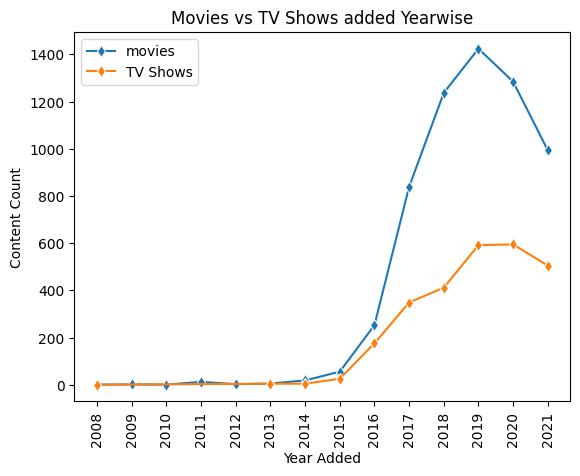

In [180]:
plt.title('Movies vs TV Shows added Yearwise')
sns.lineplot(x= year_movie, y= count_movie, marker= 'd', label= 'movies')
sns.lineplot(x= year_tv, y= count_tv, marker= 'd', label= 'TV Shows')
plt.xticks(rotation= 90)
plt.xlabel('Year Added')
plt.ylabel('Content Count')
plt.show()

**Insight And Recommendation**

*>**>Insight for Movies:** Distribution of Movies by Year Added: The data shows that the majority of movies were added to the platform in 2019, with a total of 1424 titles. This indicates a significant influx of new movie content during that year. Following closely, the years 2020 and 2018 witnessed substantial additions, with 1284 and 1237 movies added, respectively. However, there is a slight decline in the number of movies added in 2021, with 993 titles.*

*>**Insight for TV Shows:** Distribution of TV Shows by Year Added: Similarly, the data reveals that the highest number of TV shows were added in 2020, totaling 595 titles. This suggests a notable emphasis on expanding the TV show catalog during that year. In the preceding year, 2019, a comparable number of TV shows were added, with 592 titles. However, there is a slight decrease in new TV show additions in 2021, with 505 titles, indicating a potential shift in content acquisition strategies.*

*>**Overall Insight:** Content Acquisition Strategy: The insights from both movie and TV show data indicate fluctuations in content additions across different years. While there was a peak in movie additions in 2019, followed by a substantial increase in TV show additions in 2020, the subsequent years witnessed variations in content acquisition trends. This suggests that Netflix's content acquisition strategy is dynamic and responsive to changing viewer preferences, market trends, and production cycles within the entertainment industry.*

*Viewer Engagement and Retention: The distribution of new content additions across different years reflects Netflix's efforts to attract and retain subscribers by continuously refreshing its content library with a diverse selection of movies and TV shows. By analyzing viewer engagement metrics for newly added content, such as watch time, ratings, and user feedback, Netflix can optimize its content acquisition strategy to ensure a compelling and relevant viewing experience for its audience.*

*>**Recommendations:** Diversify Content Portfolio: To maintain viewer engagement and cater to diverse audience preferences, Netflix should continue diversifying its content portfolio by strategically acquiring a mix of movies and TV shows across various genres, languages, and formats. This will ensure a well-rounded entertainment offering that appeals to different demographic segments and enhances user satisfaction.*

*Strategic Content Investments: Netflix should leverage data analytics and viewer insights to identify emerging trends, popular genres, and content preferences among its target audience. By strategically investing in content production or acquisition based on predictive analytics and market research, Netflix can maximize the success of its content offerings and stay ahead of competitors.*

*Optimize Release Timing: Analyzing historical data on viewer engagement and content performance can help Netflix determine the optimal timing for releasing new movies and TV shows. By identifying peak viewing periods, seasonal trends, and audience behavior patterns, Netflix can schedule content releases strategically to maximize viewership and engagement.*

*Collaborate with Established Talent: Building strategic partnerships with renowned directors, actors, and content creators can enhance the quality and appeal of Netflix's original productions. By collaborating with established talent who have a proven track record of success, Netflix can attract a wider audience and generate buzz around its exclusive content offerings.*

*Enhance Content Discovery: Netflix should focus on improving content discovery and recommendation algorithms to help users discover relevant movies and TV shows based on their individual preferences, viewing history, and interests. By personalizing the content discovery experience and providing tailored recommendations, Netflix can increase user engagement and retention.*

*Invest in Original Content: Given the growing competition in the streaming industry, Netflix should continue investing in original content production to differentiate its platform and attract subscribers. By nurturing relationships with talented filmmakers, writers, and creators, Netflix can create a compelling lineup of exclusive content that sets it apart from competitors and drives subscriber growth.*

*Expand Global Content Catalog: To appeal to a diverse international audience, Netflix should expand its content catalog with region-specific movies and TV shows that resonate with local cultures and preferences. By licensing or producing content tailored to different regions, Netflix can strengthen its presence in international markets and attract new subscribers worldwide.*

*Engage with User Feedback: Netflix should actively engage with user feedback and incorporate user preferences and suggestions into its content acquisition and production decisions. By listening to audience feedback, responding to customer needs, and addressing concerns, Netflix can foster a strong sense of community and loyalty among its subscriber base.*

*Monitor Industry Trends: Keeping abreast of industry trends, technological advancements, and changes in consumer behavior is crucial for Netflix to stay competitive in the ever-evolving streaming landscape. By monitoring industry developments and adapting its strategies accordingly, Netflix can remain agile and responsive to shifting market dynamics.*

*Focus on Quality and Innovation: Netflix should prioritize quality and innovation in its content offerings, emphasizing storytelling excellence, production value, and creative originality. By continuously pushing the boundaries of storytelling and embracing innovative formats and technologies, Netflix can deliver immersive and unforgettable entertainment experiences that captivate audiences worldwide.*

**Best Month To Add movie**

In [181]:
data['month_added']= data['date_added'].dt.month_name()

In [182]:
data[data['type'] == 'Movie'].groupby('month_added')['show_id'].nunique().sort_values(ascending= False)

month_added
July         565
April        550
December     547
January      546
October      545
March        529
August       519
September    519
November     498
June         492
May          439
February     382
Name: show_id, dtype: int64

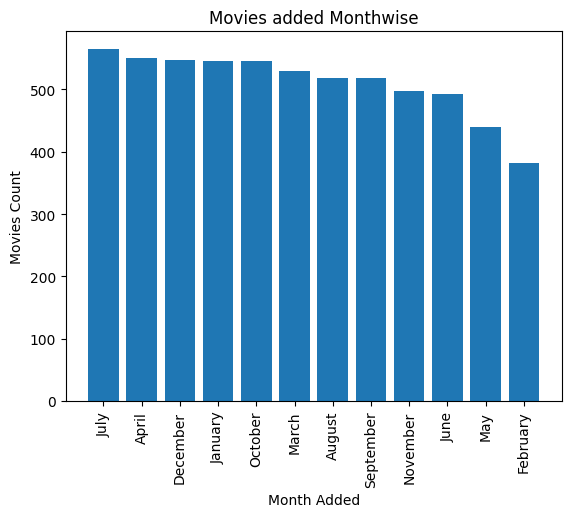

In [183]:
plt.title('Movies added Monthwise')
month_movie = data[data['type'] == 'Movie'].groupby('month_added')['show_id'].nunique().sort_values(ascending= False).index
count_movie = data[data['type'] == 'Movie'].groupby('month_added')['show_id'].nunique().sort_values(ascending= False)
plt.bar(month_movie, count_movie)
plt.xticks(rotation= 90)
plt.xlabel('Month Added')
plt.ylabel('Movies Count')
plt.show()

**Insight And Recommendation**

**>Insight:**

*Seasonal Variation: The data suggests that there is seasonal variation in the addition of movies to the Netflix platform, with certain months experiencing higher activity than others. July emerges as the peak month for movie additions, followed closely by April and December. On the other hand, February sees the lowest number of movie additions.*

*Summer Release Strategy: The spike in movie additions during July may be attributed to a strategic release strategy by Netflix to capitalize on increased viewership during the summer months. As people tend to have more leisure time and engage in indoor activities like streaming movies during the summer vacation period, Netflix may prioritize releasing new content during this time to attract and retain subscribers.*

*Holiday Season Impact: The months of December and January also witness a notable influx of movie additions, likely influenced by the holiday season. With many people spending time at home during the holidays, there is a higher demand for entertainment, prompting Netflix to bolster its content library with new movie releases to cater to holiday audiences.*

*Distribution Timing: The distribution of movie additions across different months underscores the importance of strategic timing in content acquisition and release planning. By strategically scheduling movie releases to coincide with peak viewing periods and seasonal trends, Netflix can maximize audience engagement and capitalize on evolving consumer preferences.*

**>Recommendations:**

*Capitalize on Peak Viewing Periods: Netflix should continue to capitalize on peak viewing periods, such as summer vacations and holidays, by strategically scheduling the release of high-profile movies during these times. By aligning content additions with periods of increased viewer engagement, Netflix can maximize the impact of its new releases and drive subscriber growth.*

*Diversify Release Schedule: While July emerges as the top month for movie additions, Netflix should maintain a diversified release schedule throughout the year to cater to diverse audience preferences and viewing habits. By spreading out movie releases across different months, Netflix can sustain viewer interest and engagement year-round.*

*Leverage Seasonal Themes: Netflix can leverage seasonal themes and trends to curate themed movie collections and promotional campaigns, aligning content offerings with seasonal occasions and festivities. By curating content that resonates with seasonal themes and sentiments, Netflix can enhance viewer engagement and create a more immersive streaming experience.*

*Data-Driven Decision-Making: Netflix should leverage data analytics and viewer insights to inform content acquisition and release decisions, identifying optimal release windows and content strategies based on historical viewing patterns and audience behavior. By adopting a data-driven approach to content planning, Netflix can optimize its content library and enhance viewer satisfaction.*

*Promote Content Diversity: While focusing on peak viewing periods, Netflix should also prioritize promoting content diversity and inclusivity by featuring a wide range of genres, languages, and cultural perspectives in its movie additions. By catering to diverse audience interests and preferences, Netflix can foster a more inclusive streaming platform and attract a broader subscriber base.*

*Enhance Content Discovery: To ensure that subscribers can easily discover and access newly added movies, Netflix should continue to invest in enhancing content discovery features and recommendation algorithms. By personalizing the content discovery experience and surfacing relevant movie recommendations, Netflix can improve user engagement and retention.*

**Best Month To Add TV Show**

In [184]:
data[data['type'] == 'TV Show'].groupby('month_added')['show_id'].nunique().sort_values(ascending= False)

month_added
December     266
July         262
September    251
August       236
June         236
October      215
April        214
March        213
November     207
May          193
January      192
February     181
Name: show_id, dtype: int64

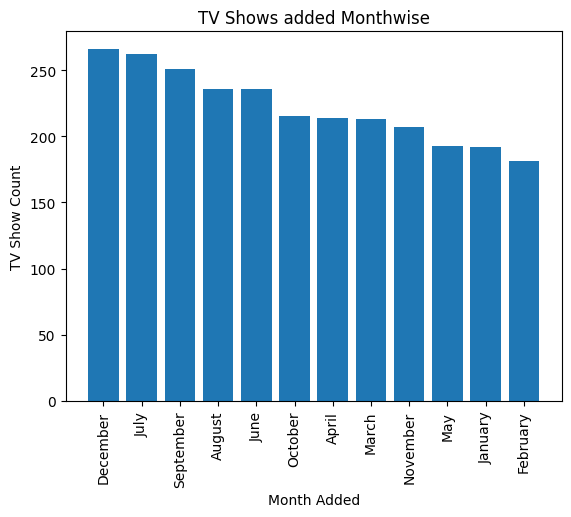

In [185]:
plt.title('TV Shows added Monthwise')
month_tv = data[data['type'] == 'TV Show'].groupby('month_added')['show_id'].nunique().sort_values(ascending= False).index
count_tv = data[data['type'] == 'TV Show'].groupby('month_added')['show_id'].nunique().sort_values(ascending= False)
plt.bar(month_tv, count_tv)
plt.xticks(rotation= 90)
plt.xlabel('Month Added')
plt.ylabel('TV Show Count')
plt.show()

**Insight And Recommendation**

**>Insights:**

*Seasonal Patterns: Similar to the trend observed for movie additions, there is a noticeable seasonal pattern in the addition of TV shows to the Netflix platform. December emerges as the peak month for TV show additions, followed closely by July and September. This suggests that certain months experience higher activity in terms of TV show releases compared to others.*

*Holiday Season Influence: The spike in TV show additions during December is likely influenced by the holiday season, during which many viewers have more leisure time and engage in binge-watching TV series. With the winter holidays being a popular time for indoor entertainment, Netflix strategically adds new TV shows to cater to increased viewer demand during this period.*

*Summer Viewing Trends: The presence of July and September among the top months for TV show additions indicates a trend of heightened viewer engagement during the summer months. As people often have more free time and are looking for entertainment options during the summer vacation period, Netflix capitalizes on this trend by releasing new TV shows to attract and retain subscribers.*

*Year-End Content Strategy: December's prominence as the top month for TV show additions also reflects Netflix's year-end content strategy, where the platform aims to end the year on a high note by adding highly anticipated TV series and exclusive content offerings. By bolstering its TV show lineup towards the end of the year, Netflix seeks to maintain subscriber engagement and drive viewer satisfaction.*

**>Recommendations:**

*Strategic Content Planning: Netflix should continue to strategically plan the release of TV shows throughout the year, with a particular focus on key months such as December, July, and September. By aligning TV show additions with seasonal viewing trends and audience preferences, Netflix can maximize viewer engagement and retention.*

*Holiday Content Promotion: To leverage the increased viewership during the holiday season, Netflix should promote newly added TV shows through targeted marketing campaigns and themed content collections. By highlighting holiday-themed series and exclusive releases, Netflix can attract more viewers and capitalize on festive viewing trends.*

*Diversify Genre Offerings: While focusing on peak months for TV show additions, Netflix should ensure a diverse range of genre offerings to cater to varied viewer preferences. By curating a mix of drama, comedy, thriller, and other genres, Netflix can appeal to a broad audience and enhance the overall content diversity on its platform.*

*Viewer Engagement Strategies: Netflix should implement viewer engagement strategies such as interactive features, social media integration, and personalized recommendations to enhance the TV show viewing experience. By encouraging viewer participation and facilitating content discovery, Netflix can foster deeper connections with its audience and foster long-term subscriber loyalty.*

*Content Quality Assurance: Prior to release, Netflix should conduct thorough quality assurance checks and audience testing to ensure that newly added TV shows meet the platform's content standards and viewer expectations. By maintaining high-quality standards and delivering compelling storytelling, Netflix can enhance viewer satisfaction and drive positive word-of-mouth recommendations.*

*Data-Driven Decision Making: Leveraging data analytics and viewer insights, Netflix should continuously evaluate the performance of TV shows and adjust its content acquisition and release strategy accordingly. By monitoring viewer engagement metrics and content consumption patterns, Netflix can make data-driven decisions to optimize its TV show lineup and deliver content that resonates with its audience.*

**Best Day To Add A Movie**

In [186]:
data['day_added']= data['date_added'].dt.day_name()

In [187]:
data[data['type'] == 'Movie'].groupby('day_added')['show_id'].nunique().sort_values(ascending= False)

day_added
Friday       1566
Thursday     1053
Wednesday     906
Tuesday       852
Monday        628
Sunday        569
Saturday      557
Name: show_id, dtype: int64

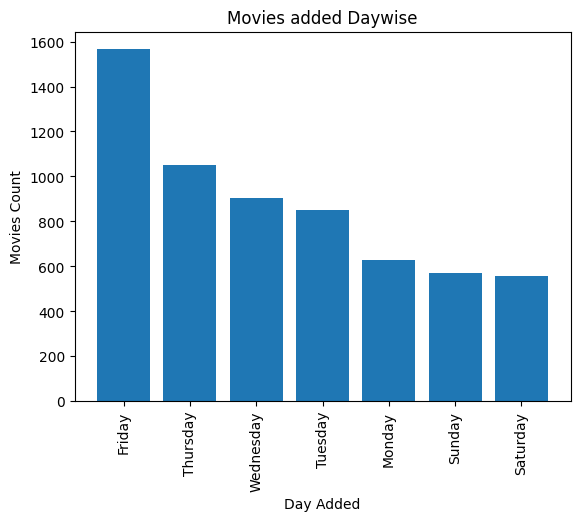

In [188]:
plt.title('Movies added Daywise')
day_movie = data[data['type'] == 'Movie'].groupby('day_added')['show_id'].nunique().sort_values(ascending= False).index
count_movie = data[data['type'] == 'Movie'].groupby('day_added')['show_id'].nunique().sort_values(ascending= False)
plt.bar(day_movie, count_movie)
plt.xticks(rotation= 90)
plt.xlabel('Day Added')
plt.ylabel('Movies Count')
plt.show()

**Insight And Recommendation**

**>Insights:**

*Prime Release Day: Friday emerges as the most preferred day for adding movies to the Netflix platform, with a significant majority of movie additions occurring on this day. This trend aligns with industry standards and consumer behavior patterns, as Friday is traditionally considered the optimal day for entertainment releases, including movie premieres in theaters and digital platforms.*

*Weekend Viewing Habits: The choice of Friday for movie additions reflects Netflix's strategic approach to capitalize on weekend viewing habits and leisure time. With many people looking for entertainment options to unwind and relax after a busy week, Netflix strategically releases new movies on Fridays to attract viewers and encourage binge-watching sessions over the weekend.*

*Audience Engagement: The high volume of movie additions on Fridays indicates a deliberate effort by Netflix to engage its audience and generate excitement around new releases. By timing movie additions to coincide with the start of the weekend, Netflix maximizes the potential for viewer engagement and interaction with its platform.*

*Content Promotion Opportunities: Netflix can leverage the popularity of Friday movie releases to implement targeted marketing campaigns and promotional activities. By highlighting newly added movies through social media, email newsletters, and homepage features, Netflix can drive awareness and interest among subscribers, leading to increased viewership and engagement.*

*Content Variety and Selection: To maintain viewer interest and cater to diverse preferences, Netflix should ensure a steady stream of high-quality movie releases across different genres and categories. By curating a diverse selection of movies spanning genres such as drama, comedy, action, and thriller, Netflix can appeal to a broad audience and enhance the overall viewing experience.*

*Viewer Feedback and Analytics: Netflix should actively monitor viewer feedback and engagement metrics to assess the performance of newly added movies and refine its content strategy accordingly. By analyzing viewer ratings, reviews, and viewing patterns, Netflix can identify trends, preferences, and opportunities for improvement, allowing for more informed decision-making in content acquisition and release scheduling.*

**>Recommendations:**

*Continuation of Release Strategy: Netflix should continue to prioritize Friday as the primary day for adding movies to its platform, leveraging the inherent appeal of weekend viewing and leisure time to attract and retain subscribers.*

*Enhanced Content Promotion: Netflix should enhance its promotional efforts around Friday movie releases, utilizing targeted advertising, social media campaigns, and personalized recommendations to drive awareness and engagement. By showcasing upcoming releases and exclusive content offerings, Netflix can create anticipation and excitement among viewers.*

*Strategic Partnerships and Collaborations: Netflix should explore partnerships and collaborations with filmmakers, studios, and production companies to secure exclusive rights to high-profile movie releases. By acquiring sought-after titles and offering exclusive premieres, Netflix can differentiate its content library and attract subscribers seeking premium entertainment options.*

*Seasonal and Holiday Programming: Netflix should capitalize on seasonal and holiday programming opportunities by curating themed movie collections and releasing festive-themed movies during relevant periods. By aligning movie additions with cultural events and holidays, Netflix can capitalize on seasonal viewing trends and enhance viewer engagement.*

*Data-Driven Content Curation: Leveraging data analytics and viewer insights, Netflix should continuously evaluate the performance of movies and adjust its content acquisition strategy based on audience preferences and trends. By leveraging viewer feedback and engagement metrics, Netflix can optimize its movie lineup to deliver content that resonates with its audience and drives long-term subscriber satisfaction.*

**Best Day To Add A TV Show**

In [189]:
data[data['type'] == 'TV Show'].groupby('day_added')['show_id'].nunique().sort_values(ascending= False)

day_added
Friday       932
Wednesday    382
Tuesday      345
Thursday     343
Saturday     259
Monday       223
Sunday       182
Name: show_id, dtype: int64

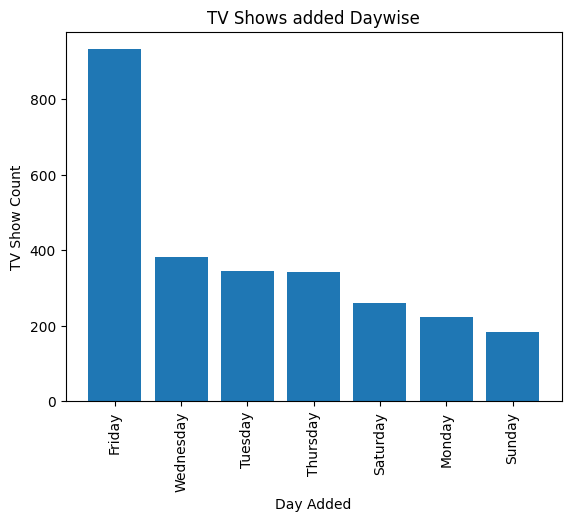

In [190]:
plt.title('TV Shows added Daywise')
day_tv = data[data['type'] == 'TV Show'].groupby('day_added')['show_id'].nunique().sort_values(ascending= False).index
count_tv = data[data['type'] == 'TV Show'].groupby('day_added')['show_id'].nunique().sort_values(ascending= False)
plt.bar(day_tv, count_tv)
plt.xticks(rotation= 90)
plt.xlabel('Day Added')
plt.ylabel('TV Show Count')
plt.show()

**Insight And Recommendation**


**>Insights:**

*Prime Release Day: Friday emerges as the most preferred day for adding TV shows to the Netflix platform, with a significant majority of TV show additions occurring on this day. This trend aligns with industry standards and consumer behavior patterns, as Friday is traditionally considered a prime day for entertainment releases and leisure activities.*

*Weekend Viewing Habits: The choice of Friday for TV show additions reflects Netflix's strategic approach to capitalize on weekend viewing habits and audience engagement. With many people looking for new content to watch during their leisure time over the weekend, Netflix strategically releases TV shows on Fridays to attract viewers and encourage binge-watching sessions.*

*Audience Engagement: The high volume of TV show additions on Fridays indicates a deliberate effort by Netflix to engage its audience and drive viewership. By timing TV show releases to coincide with the start of the weekend, Netflix maximizes the potential for viewer engagement and interaction with its platform*

*Content Diversity: Netflix should ensure a diverse range of TV shows across various genres and formats to cater to the preferences of its global audience. By curating a rich and varied selection of TV shows, including dramas, comedies, documentaries, and reality TV, Netflix can appeal to different viewer demographics and enhance the overall viewing experience.*

*Content Promotion Strategies: Netflix should leverage its promotional channels and marketing campaigns to create awareness and anticipation around new TV show releases. By utilizing social media, email newsletters, and targeted advertising, Netflix can effectively promote upcoming TV shows and generate excitement among subscribers.*

*Viewer Feedback and Analytics: Netflix should closely monitor viewer feedback and engagement metrics to gauge the performance of newly added TV shows and make data-driven decisions. By analyzing viewer ratings, reviews, and viewing behavior, Netflix can gain valuable insights into audience preferences and adjust its content strategy accordingly.*

**>Recommendations:**

*Continued Emphasis on Friday Releases: Netflix should continue to prioritize Friday as the primary day for adding TV shows to its platform, leveraging the inherent appeal of weekend viewing and leisure time to attract and retain subscribers.*

*Enhanced Marketing and Promotion: Netflix should invest in targeted marketing campaigns and promotional activities to create buzz and anticipation around Friday TV show releases. By highlighting exclusive content offerings and showcasing upcoming releases, Netflix can drive viewer engagement and subscription growth.*

*Collaboration and Partnerships: Netflix should explore partnerships and collaborations with content creators, production studios, and talent agencies to secure exclusive rights to high-quality TV shows. By offering unique and original content, Netflix can differentiate its platform and attract subscribers seeking premium entertainment options.*

*Seasonal and Event-Based Programming: Netflix should capitalize on seasonal and event-based programming opportunities by curating themed TV show collections and releasing content relevant to cultural events and holidays. By aligning TV show additions with seasonal trends and audience interests, Netflix can enhance viewer engagement and retention.*

*Personalized Recommendations: Netflix should leverage its recommendation algorithms and user data to deliver personalized content recommendations to subscribers. By analyzing viewing preferences and behavior patterns, Netflix can suggest relevant TV shows to individual users, increasing content discovery and viewer satisfaction.*

**Best Week To Add A Movie and TV Show**

In [191]:
data['week_added']= data['date_added'].dt.week

<ipython-input-191-d4f68e2e613e>:1: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated. Please use Series.dt.isocalendar().week instead.
  data['week_added']= data['date_added'].dt.week


**Best Week To Add A Movie**

In [192]:
data[data['type'] == 'Movie'].groupby('week_added')['show_id'].nunique().sort_values(ascending= False).head(10)

week_added
1.0     316
44.0    243
40.0    215
9.0     207
26.0    195
35.0    189
31.0    185
13.0    174
18.0    173
27.0    154
Name: show_id, dtype: int64

*>**Insight:** 1st Week of the year is the best week to add a movie with 316 movies added that week.*

**Best Week To Add A TV Show**

In [193]:
data[data['type'] == 'TV Show'].groupby('week_added')['show_id'].nunique().sort_values(ascending= False).head(10)

week_added
27.0    86
31.0    83
13.0    76
44.0    75
24.0    75
35.0    74
5.0     73
26.0    73
40.0    72
50.0    70
Name: show_id, dtype: int64

*>**Insight:** 27th Week of the year is the best week to add a TV Show with 86 TV Shows added that week.*

**Best Week- Movie Vs. TV Show**

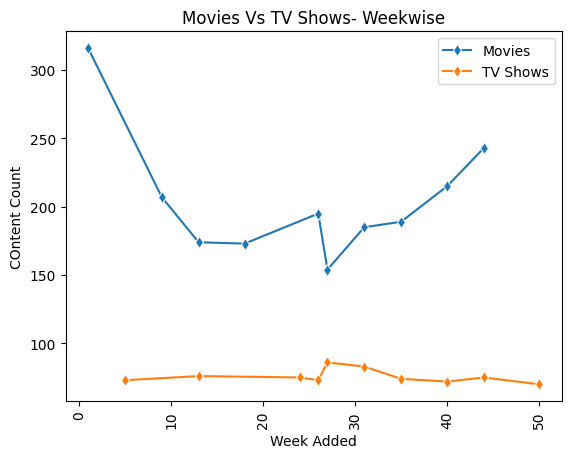

In [194]:
plt.title('Movies Vs TV Shows- Weekwise')
week_movie= data[data['type'] == 'Movie'].groupby('week_added')['show_id'].nunique().sort_values(ascending= False).head(10).index
count_movie= data[data['type'] == 'Movie'].groupby('week_added')['show_id'].nunique().sort_values(ascending= False).head(10)
week_tv= data[data['type'] == 'TV Show'].groupby('week_added')['show_id'].nunique().sort_values(ascending= False).head(10).index
count_tv= data[data['type'] == 'TV Show'].groupby('week_added')['show_id'].nunique().sort_values(ascending= False).head(10)
sns.lineplot(x= week_movie, y= count_movie, marker= 'd', label= 'Movies')
sns.lineplot(x= week_tv, y= count_tv, marker= 'd', label= 'TV Shows')
plt.xticks(rotation= 90)
plt.xlabel('Week Added')
plt.ylabel('COntent Count')
plt.show()

**Insight And Recommendation**

**>Insights:**

*Strategic Timing: The data reveals specific weeks of the year when Netflix tends to add a higher number of movies and TV shows to its platform. Understanding these peak weeks can help Netflix optimize its content release schedule and capitalize on viewer engagement opportunities.*

*New Year Impact: The first week of the year emerges as the prime time for adding movies to Netflix, with a notable surge in movie additions during this period. This trend can be attributed to the start of a new year, when viewers are eager for fresh content and may have more leisure time to indulge in movie watching.*

*Seasonal Trends: The choice of the 27th week of the year for adding TV shows suggests a potential correlation with seasonal viewing patterns or programming strategies. This particular week may coincide with school holidays, vacation seasons, or cultural events, leading to increased viewership and demand for TV show content.*

*Viewer Engagement Opportunities: Netflix can leverage the insights from peak weeks to strategically plan its content releases and promotional activities. By aligning new movie and TV show additions with periods of heightened viewer engagement, such as holidays or special occasions, Netflix can enhance audience satisfaction and retention.*

*Content Diversity: Netflix should ensure a diverse range of content offerings across genres, formats, and themes to cater to varying viewer preferences during peak weeks. By curating a well-rounded selection of movies and TV shows, Netflix can appeal to different audience segments and maximize viewership opportunities.*

*Data-Driven Decision Making: Netflix should continue to analyze viewer behavior and engagement metrics to identify trends, patterns, and opportunities for content optimization. By leveraging data-driven insights, Netflix can refine its content strategy, improve user experience, and drive subscriber growth.*

**>Recommendations:**

*Content Cadence Optimization: Netflix should prioritize the release of high-profile movie titles during the first week of the year to capitalize on viewers' heightened interest in new content. By strategically timing movie additions to coincide with the start of the year, Netflix can attract attention and generate buzz among subscribers.*

*Seasonal Content Planning: Netflix should develop a seasonal content calendar that aligns with peak viewing periods and audience preferences throughout the year. By strategically scheduling TV show releases during weeks associated with increased viewership, Netflix can maximize the impact of its content offerings and maintain audience engagement.*

*Promotional Campaigns: Netflix should implement targeted marketing campaigns and promotional strategies to promote new movie and TV show additions during peak weeks. By leveraging social media, email newsletters, and digital advertising channels, Netflix can generate excitement and anticipation around its content releases, driving subscriber engagement and retention.*

*Variety and Selection: Netflix should diversify its content library to include a wide range of movies and TV shows across genres, languages, and cultures. By offering a diverse selection of content, Netflix can cater to the preferences of its global audience and ensure there is something for everyone to enjoy during peak viewing weeks.*

*Viewer Feedback Integration: Netflix should actively solicit feedback from subscribers and incorporate user preferences into its content planning and decision-making processes. By listening to viewer input and adapting its content strategy accordingly, Netflix can enhance customer satisfaction and loyalty, ultimately driving long-term success in the streaming market.*

**Best Day And Month To Add Movie**

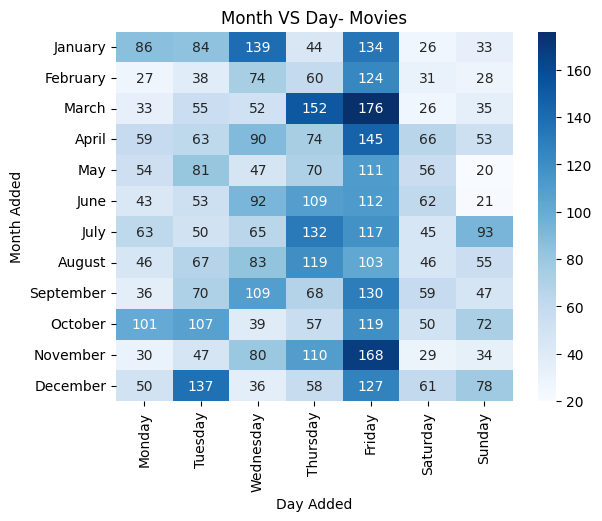

In [195]:
data_pivot_movies= data[data['type'] == 'Movie'].pivot_table(index= 'month_added', columns= 'day_added', values= 'show_id', aggfunc= pd.Series.nunique, fill_value= 0)
data_pivot_movies.index.name= None
data_pivot_movies= data_pivot_movies.loc[['January', 'February', 'March', 'April', 'May', 'June','July', 'August', 'September', 'October', 'November', 'December'], ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']]
plt.title('Month VS Day- Movies')
sns.heatmap(data_pivot_movies, annot= True, fmt= 'd', cmap= 'Blues')
plt.xlabel('Day Added')
plt.ylabel('Month Added')
plt.show()

In [196]:
data_pivot_movies

day_added,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
January,86,84,139,44,134,26,33
February,27,38,74,60,124,31,28
March,33,55,52,152,176,26,35
April,59,63,90,74,145,66,53
May,54,81,47,70,111,56,20
June,43,53,92,109,112,62,21
July,63,50,65,132,117,45,93
August,46,67,83,119,103,46,55
September,36,70,109,68,130,59,47
October,101,107,39,57,119,50,72


**Co-Relation**

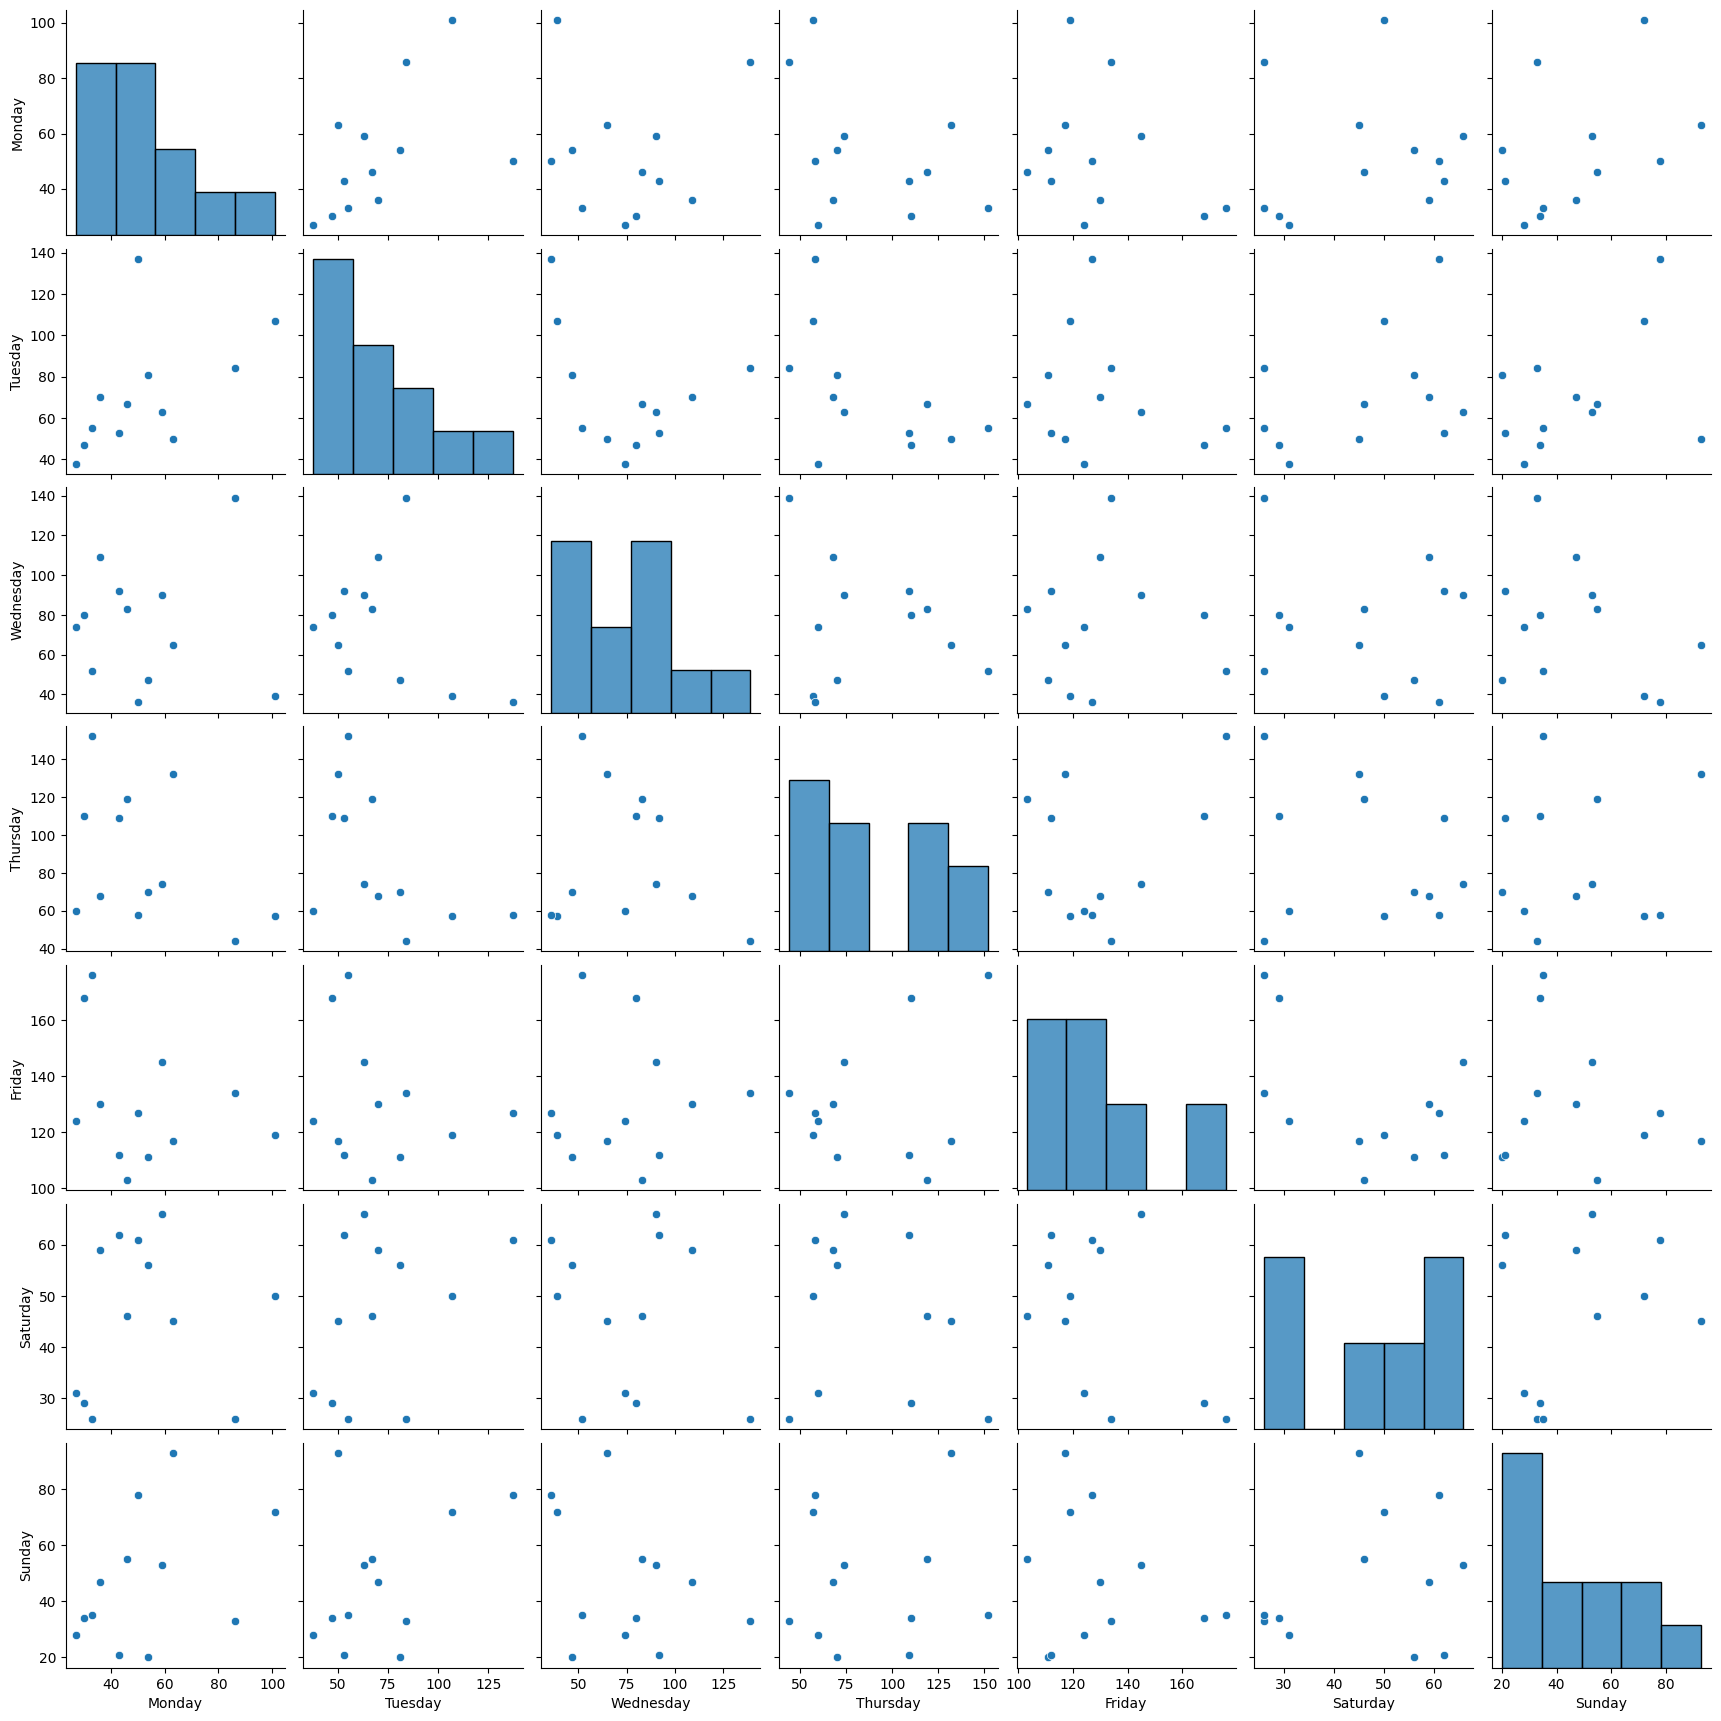

In [197]:
sns.pairplot(data= data_pivot_movies)
plt.show()

**Insight And Recommendation**

**>Insights:**

*Weekly Variation: The data illustrates fluctuations in the number of movies added to Netflix throughout the week, with different days experiencing varying levels of activity. Understanding these trends can help Netflix optimize its content release schedule and maximize audience engagement opportunities.*

*Peak Activity: Fridays emerge as the busiest day for adding movies to Netflix, with consistently higher numbers compared to other days of the week. This trend suggests that Fridays are strategically favored for premiering new content, likely to capitalize on viewers' weekend leisure time and entertainment consumption habits.*

*Seasonal Dynamics: The month of March stands out as a period of heightened movie additions, particularly on Thursdays and Fridays. This could be attributed to factors such as the release of highly anticipated movies, promotional campaigns, or industry trends influencing content acquisition and distribution strategies.*

*Audience Preferences: Netflix should leverage insights from peak days and months to curate content offerings that resonate with viewer preferences and behavior patterns. By aligning new movie releases with days and months associated with higher viewership, Netflix can enhance user engagement and satisfaction.*

*Strategic Planning: Netflix should employ data-driven decision-making processes to strategically plan content releases, promotional campaigns, and marketing initiatives. By analyzing historical trends and audience feedback, Netflix can optimize its content strategy to meet evolving viewer demands and preferences.*

**>Recommendations:**

*Promotional Events: Netflix should capitalize on the popularity of Fridays by strategically scheduling high-profile movie releases and promotional events to coincide with this peak activity day. Leveraging Fridays for premieres can generate excitement and anticipation among subscribers, driving engagement and retention.*

*Content Diversity: Netflix should ensure a diverse range of movie offerings across genres, languages, and formats to appeal to a broad audience base. By curating a well-rounded selection of movies, Netflix can cater to diverse viewer preferences and enhance the overall content discovery experience.*

*Data-Driven Insights: Netflix should continue to analyze viewer behavior and engagement metrics to identify trends, patterns, and opportunities for content optimization. By leveraging data-driven insights, Netflix can refine its content strategy, improve user experience, and drive subscriber growth.*

*Strategic Partnerships: Netflix should explore strategic partnerships and collaborations with filmmakers, studios, and content creators to secure exclusive rights to high-quality movies and enhance its content library. By acquiring exclusive content, Netflix can differentiate its platform and attract new subscribers while retaining existing ones.*

*Seasonal Campaigns: Netflix should develop targeted marketing campaigns and promotional initiatives to coincide with peak activity days and months, such as March Fridays. By leveraging seasonal dynamics and audience preferences, Netflix can maximize the impact of its content releases and drive engagement across its platform.*

**Best Day And Month To Add TV Show**

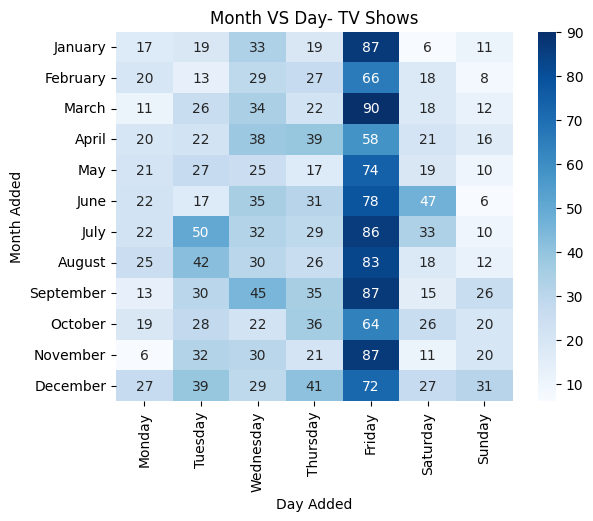

In [198]:
data_pivot_tv= data[data['type'] == 'TV Show'].pivot_table(index= 'month_added', columns= 'day_added', values= 'show_id', aggfunc= pd.Series.nunique, fill_value= 0)
data_pivot_tv.index.name= None
data_pivot_tv= data_pivot_tv.loc[['January', 'February', 'March', 'April', 'May', 'June','July', 'August', 'September', 'October', 'November', 'December'], ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']]
plt.title('Month VS Day- TV Shows')
sns.heatmap(data_pivot_tv, annot= True, fmt= 'd', cmap= 'Blues')
plt.xlabel('Day Added')
plt.ylabel('Month Added')
plt.show()

In [199]:
data_pivot_tv

day_added,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
January,17,19,33,19,87,6,11
February,20,13,29,27,66,18,8
March,11,26,34,22,90,18,12
April,20,22,38,39,58,21,16
May,21,27,25,17,74,19,10
June,22,17,35,31,78,47,6
July,22,50,32,29,86,33,10
August,25,42,30,26,83,18,12
September,13,30,45,35,87,15,26
October,19,28,22,36,64,26,20


**Co-Relation**

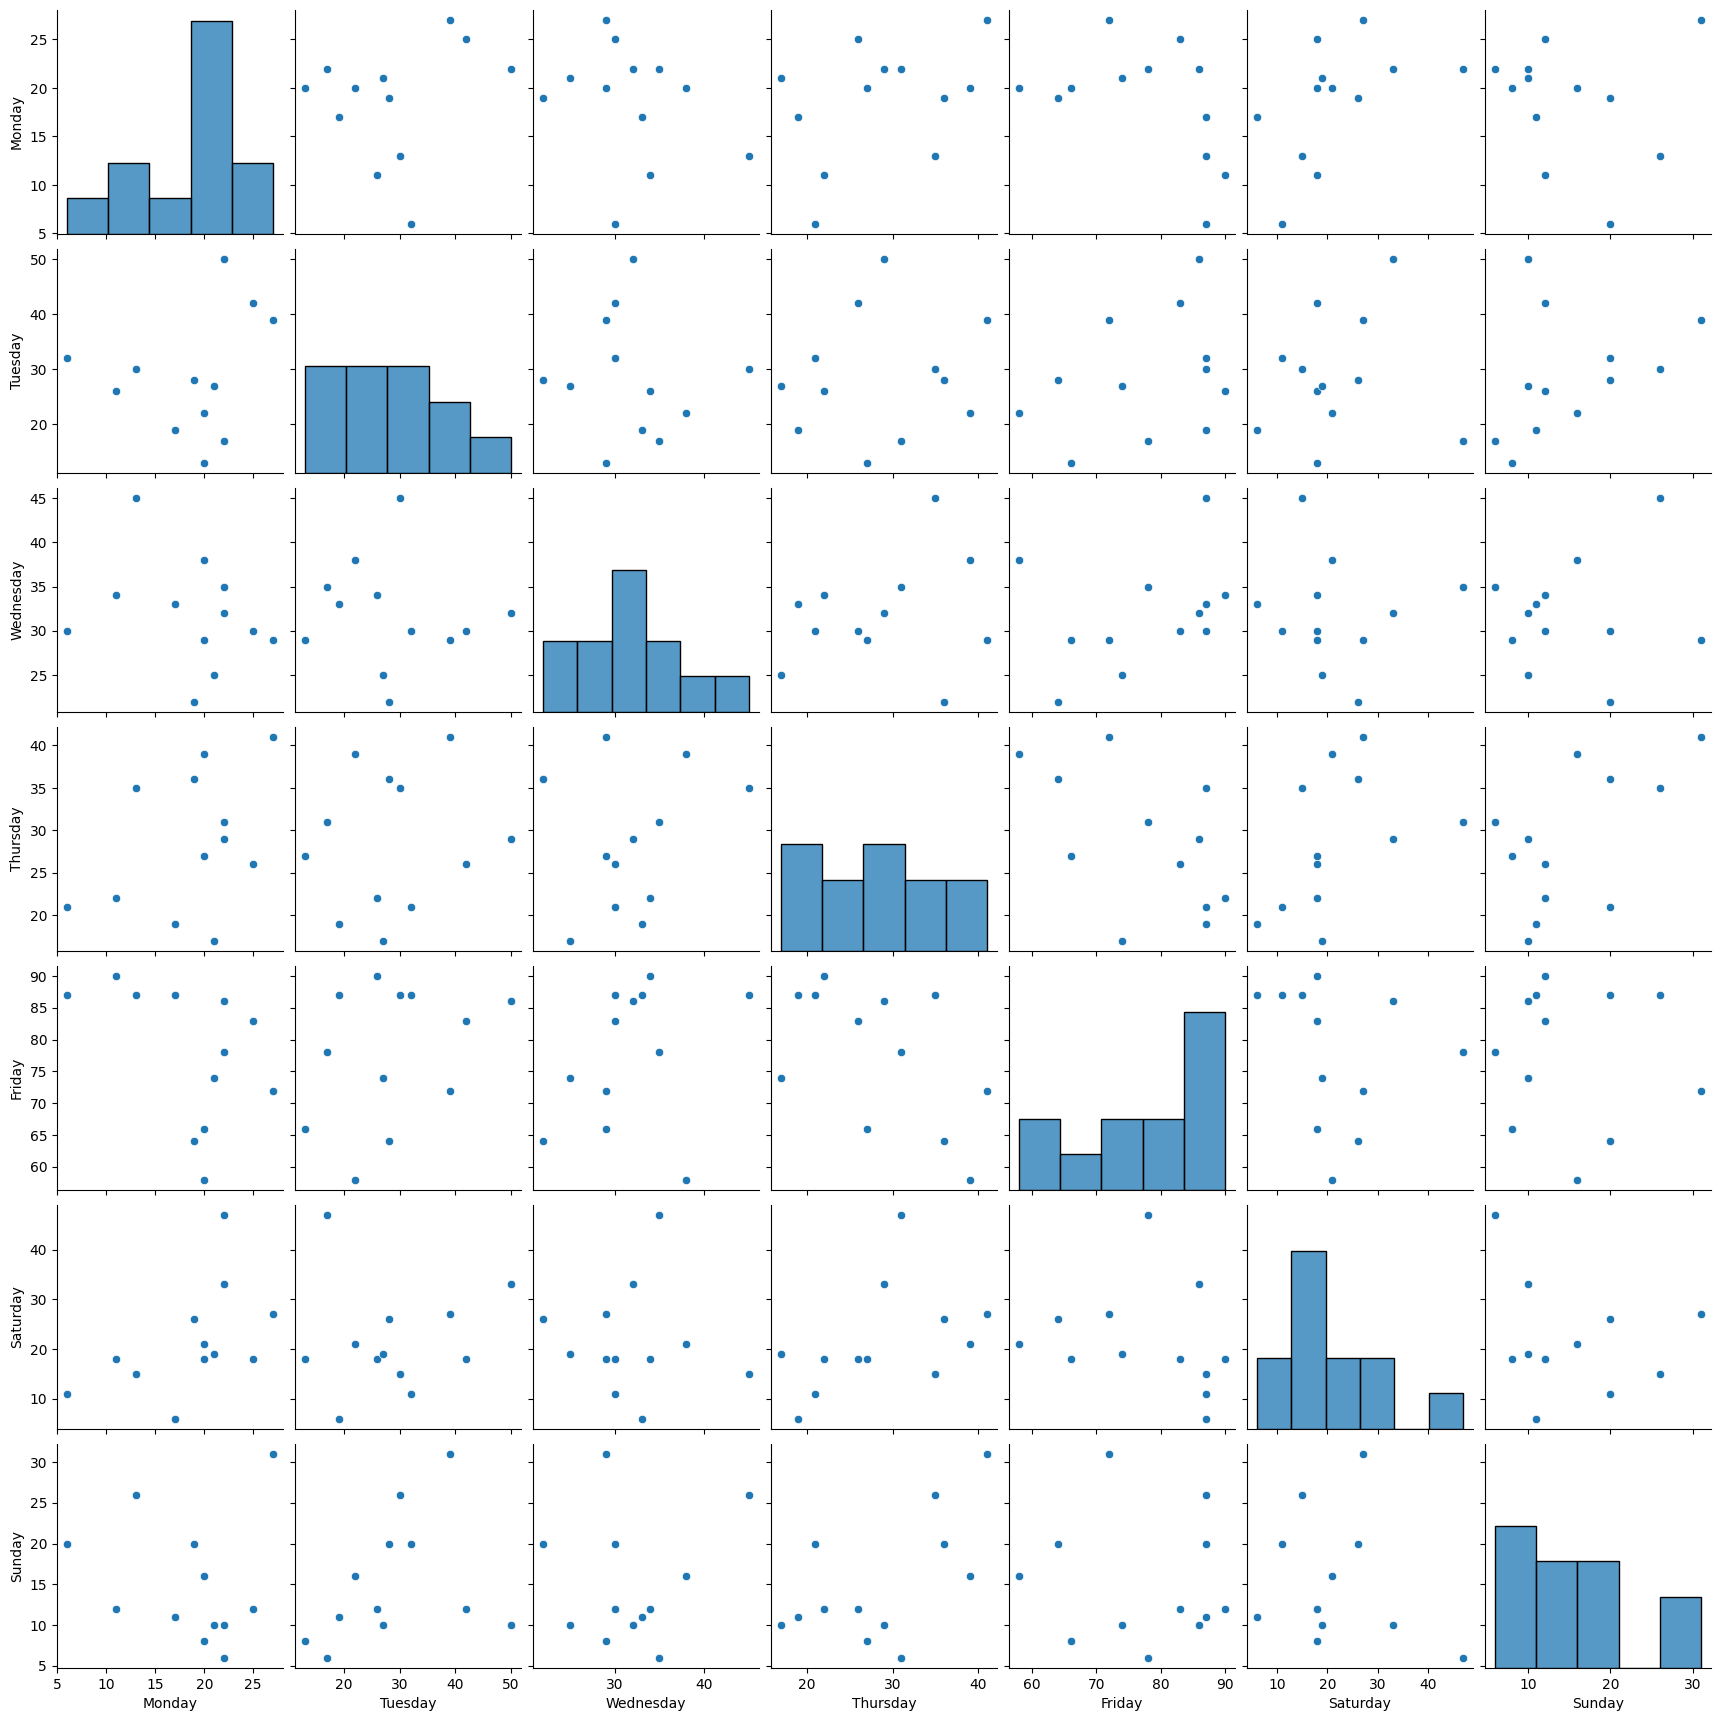

In [200]:
sns.pairplot(data= data_pivot_tv)
plt.show()

**Insight And Recommendation**

**>Insights:**

*Weekly Variation: Similar to movies, TV show additions exhibit variability throughout the week, with different days experiencing varying levels of activity. Understanding these patterns can assist Netflix in optimizing its TV show release strategy to maximize viewer engagement.*

*Peak Activity: Fridays emerge as the busiest day for adding TV shows to Netflix, with consistently higher numbers compared to other days of the week. This trend suggests that Fridays are strategically favored for premiering new TV content, likely to coincide with viewers' weekend leisure time and binge-watching habits.*

*Seasonal Dynamics: March stands out as a month of heightened TV show additions, particularly on Fridays. This could be attributed to factors such as the release of popular TV series, seasonal promotions, or strategic content acquisitions aimed at attracting and retaining subscribers.*

*Viewer Preferences: Netflix should leverage insights from peak days and months to curate TV show offerings that align with viewer preferences and viewing habits. By analyzing historical trends and audience feedback, Netflix can tailor its content strategy to deliver compelling TV shows that resonate with subscribers.*

*Strategic Planning: Netflix should utilize data-driven insights to inform its TV show release schedule, promotional campaigns, and content acquisition decisions. By leveraging analytics and audience metrics, Netflix can optimize its TV show strategy to enhance viewer satisfaction and platform engagement.*

**>Recommendations:**

*Strategic Premieres: Netflix should strategically schedule TV show premieres on Fridays to capitalize on peak viewership and maximize audience reach. Leveraging Fridays for new TV releases can generate excitement among subscribers and drive binge-watching behavior over the weekend.*

*Diverse Content Portfolio: Netflix should diversify its TV show offerings across genres, formats, and languages to cater to a wide range of viewer preferences. By curating a diverse content portfolio, Netflix can appeal to different audience segments and strengthen its position as a leading streaming platform.*

*Data-Driven Decision Making: Netflix should continue to analyze viewer behavior and engagement metrics to identify emerging trends and opportunities in the TV show landscape. By leveraging data-driven insights, Netflix can refine its content strategy and optimize the performance of its TV show catalog.*

*Exclusive Partnerships: Netflix should explore exclusive partnerships and collaborations with content creators, production studios, and TV networks to secure rights to high-quality TV shows. By acquiring exclusive content, Netflix can differentiate its platform and attract subscribers seeking premium and original programming.*

*Seasonal Campaigns: Netflix should develop targeted marketing campaigns and promotional initiatives to coincide with peak activity days and months, such as Fridays in March. By leveraging seasonal dynamics and audience preferences, Netflix can amplify the impact of its TV show releases and drive viewer engagement across its platform.*

# **4. Analysis Of Actors/Directors Of Different Types Of Shows/Movies.**

a. Identify the top 10 directors who have appeared in most movies or TV shows.
Hint : We want you to group by each actor and find the count of unique titles of
Tv-shows/movies
b. Identify the top 10 directors who have appeared in most movies or TV shows.
Hint : We want you to group by each director and find the count of unique titles
of Tv-shows/movies

**Top 10 Popular Actors**

In [201]:
data_unnested.loc[data_unnested['cast'] != 'unknown_cast'].groupby('cast')['show_id'].nunique().sort_values(ascending= False).head(10)

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Amitabh Bachchan    28
Name: show_id, dtype: int64

*>**Insight:** It is evident that 'Anupam Kher' is the most popular artist on our platform, having acted in 43 projects overall.*

**Top 10 Popular Actors In Movies**

In [202]:
data_unnested.loc[(data_unnested['cast'] != 'unknown_cast') & (data_unnested['type'] == 'Movie')].groupby('cast')['show_id'].nunique().sort_values(ascending= False).head(10)

cast
Anupam Kher         42
Shah Rukh Khan      35
Naseeruddin Shah    32
Akshay Kumar        30
Om Puri             30
Paresh Rawal        28
Amitabh Bachchan    28
Julie Tejwani       28
Boman Irani         27
Rupa Bhimani        27
Name: show_id, dtype: int64

*>**Insight:** It is evident that 'Anupam Kher' is the most popular artist in Movies, having acted in 42 Movies.*

**Most Popular Actors-Genre Pair In Movies**

In [203]:
data_unnested.loc[(data_unnested['cast'] != 'unknown_cast') & (data_unnested['type'] == 'Movie')].groupby(['cast','listed_in'])['show_id'].nunique().sort_values(ascending= False).head(10)

cast              listed_in               
Anupam Kher       International Movies        38
Shah Rukh Khan    International Movies        32
Naseeruddin Shah  Dramas                      28
Shah Rukh Khan    Dramas                      28
Anupam Kher       Dramas                      28
Akshay Kumar      International Movies        27
Naseeruddin Shah  International Movies        27
Om Puri           International Movies        27
Julie Tejwani     Children & Family Movies    26
Kareena Kapoor    International Movies        25
Name: show_id, dtype: int64

*>**Insight:** The list above showcases the most popular actor-genre combinations in Movies. 'Anupam Kher' in 'International Movies' emerging as the most popular combination*

**Top 10 Popoular Actor In TV Shows**

In [204]:
data_unnested.loc[(data_unnested['cast'] != 'unknown_cast') & (data_unnested['type'] == 'TV Show')].groupby('cast')['show_id'].nunique().sort_values(ascending= False).head(10)

cast
Takahiro Sakurai      25
Yuki Kaji             19
Junichi Suwabe        17
Daisuke Ono           17
Ai Kayano             17
Yuichi Nakamura       16
Yoshimasa Hosoya      15
Jun Fukuyama          15
David Attenborough    14
Kana Hanazawa         13
Name: show_id, dtype: int64

*>**Insight:** It is observed that 'Takahiro Sakurai' is the most popular artist in TV Shows, having acted in 25 TV Shows.*

**Most Popular Actors-Genre Pair In TV Shows**

In [205]:
data_unnested.loc[(data_unnested['cast'] != 'unknown_cast') & (data_unnested['type'] == 'TV Show')].groupby(['cast','listed_in'])['show_id'].nunique().sort_values(ascending= False).head(10)

cast              listed_in             
Takahiro Sakurai  Anime Series              24
                  International TV Shows    22
Yuki Kaji         International TV Shows    18
                  Anime Series              18
Ai Kayano         Anime Series              17
Yuichi Nakamura   Anime Series              16
Junichi Suwabe    International TV Shows    16
Ai Kayano         International TV Shows    16
Daisuke Ono       Anime Series              16
Junichi Suwabe    Anime Series              16
Name: show_id, dtype: int64

*>**Insight:** The list above showcases the most popular actor-genre combinations in TV Shows, with 'Takahiro Sakurai' in 'Anime Series' emerging as the most popular combination*

**Top 10 Popular Directors**

In [206]:
data_unnested.loc[(data_unnested['director'] != 'unknown_director')].groupby('director')['show_id'].nunique().sort_values(ascending= False).head(10)

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Jay Chapman            12
Martin Scorsese        12
Name: show_id, dtype: int64

*>**Insight:** It is observed that 'Rajiv Chilaka' is the most popular director on our platform, having directed 22 projects overall*

**Top 10 Popular Directors In TV Shows**

In [207]:
data_unnested.loc[(data_unnested['director'] != 'unknown_director') & (data_unnested['type'] == 'TV Show')].groupby('director')['show_id'].nunique().sort_values(ascending= False).head(10)

director
Ken Burns                3
Alastair Fothergill      3
Stan Lathan              2
Jung-ah Im               2
Joe Berlinger            2
Hsu Fu-chun              2
Gautham Vasudev Menon    2
Lynn Novick              2
Iginio Straffi           2
Shin Won-ho              2
Name: show_id, dtype: int64

*>**Insight:** It is observed that 'Ken Burns' & 'Alastair Fothergill' are the most popular directors in TV Show, having directed 3 projects each*

**Most Popular Director-Genre Pair In TV Shows**

In [208]:
data_unnested.loc[(data_unnested['director'] != 'unknown_director') & (data_unnested['type'] == 'TV Show')].groupby(['director', 'listed_in'])['title'].nunique().sort_values(ascending= False).head(10)

director             listed_in                   
Alastair Fothergill  International TV Shows          3
                     Docuseries                      3
                     British TV Shows                3
Ken Burns            Docuseries                      3
Stan Lathan          TV Comedies                     2
Shin Won-ho          Romantic TV Shows               2
Lynn Novick          Docuseries                      2
Stan Lathan          Stand-Up Comedy & Talk Shows    2
Hsu Fu-chun          International TV Shows          2
                     Romantic TV Shows               2
Name: title, dtype: int64

*>**Insight:** The list above showcases the most popular director-genre combinations in TV Shows, with 'Alastair Fothergill' in 'International TV Shows' emerging as the most popular combination*

**Top 10 Popular Directors In Movie**

In [209]:
data_unnested.loc[(data_unnested['director'] != 'unknown_director') & (data_unnested['type'] == 'Movie')].groupby('director')['show_id'].nunique().sort_values(ascending= False).head(10)

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           15
Jay Karas              15
Cathy Garcia-Molina    13
Jay Chapman            12
Martin Scorsese        12
Youssef Chahine        12
Name: show_id, dtype: int64

*>**Insight:** It is observed that 'Rajiv Chilaka' is the most popular director in Movies on our platform, having directed 22 movies.*

**Most Popular Director-Genre Pair In Movies**

In [210]:
data_unnested.loc[(data_unnested['director'] != 'unknown_director') & (data_unnested['type'] == 'Movie')].groupby(['director', 'listed_in'])['title'].nunique().sort_values(ascending= False).head(10)

director             listed_in               
Rajiv Chilaka        Children & Family Movies    22
Jan Suter            Stand-Up Comedy             21
Raúl Campos          Stand-Up Comedy             19
Suhas Kadav          Children & Family Movies    16
Marcus Raboy         Stand-Up Comedy             15
Jay Karas            Stand-Up Comedy             14
Cathy Garcia-Molina  International Movies        13
Jay Chapman          Stand-Up Comedy             12
Youssef Chahine      Dramas                      12
                     International Movies        10
Name: title, dtype: int64

*>**Insight:** The list above showcases the most popular director-genre combinations in Movies, with 'Rajiv Chilaka' in 'Children & Family Movies' emerging as the most popular combination*

**Best Director-Actor Pair Overall**

In [211]:
data_unnested.loc[(data_unnested['cast'] != 'unknown_cast') & (data_unnested['director'] != 'unknown_director')].groupby(['director', 'cast'])['show_id'].nunique().sort_values(ascending= False).head(10)

director        cast              
Rajiv Chilaka   Julie Tejwani         19
                Rajesh Kava           19
                Jigna Bhardwaj        18
                Rupa Bhimani          18
                Vatsal Dubey          16
                Swapnil               13
                Mousam                13
Suhas Kadav     Saurav Chakraborty     8
Yılmaz Erdoğan  Yılmaz Erdoğan         7
S.S. Rajamouli  Sathyaraj              7
Name: show_id, dtype: int64

In [212]:
data_unnested.loc[(data_unnested['cast'] != 'unknown_cast') & (data_unnested['director'] != 'unknown_director')].groupby(['director', 'cast'])['show_id'].nunique().sort_values(ascending= False).head().reset_index().iloc[0]

director    Rajiv Chilaka
cast        Julie Tejwani
show_id                19
Name: 0, dtype: object

*>**Insight:** The best director-actor pair is 'Rajiv Chilaka' with 'Julie Tejwani', having collaborated on 19 projects together overall*

**Best Director-Actor-Genre Pair Overall**

In [213]:
data_unnested.loc[(data_unnested['cast'] != 'unknown_cast') & (data_unnested['director'] != 'unknown_director')].groupby(['director', 'cast', 'listed_in'])['show_id'].nunique().sort_values(ascending= False).head(10)

director           cast                listed_in               
Rajiv Chilaka      Julie Tejwani       Children & Family Movies    19
                   Rajesh Kava         Children & Family Movies    19
                   Jigna Bhardwaj      Children & Family Movies    18
                   Rupa Bhimani        Children & Family Movies    18
                   Vatsal Dubey        Children & Family Movies    16
                   Swapnil             Children & Family Movies    13
                   Mousam              Children & Family Movies    13
Suhas Kadav        Saurav Chakraborty  Children & Family Movies     8
Yılmaz Erdoğan     Yılmaz Erdoğan      International Movies         7
Toshiya Shinohara  Satsuki Yukino      International Movies         7
Name: show_id, dtype: int64

In [214]:
data_unnested.loc[(data_unnested['cast'] != 'unknown_cast') & (data_unnested['director'] != 'unknown_director')].groupby(['director', 'cast', 'listed_in'])['show_id'].nunique().sort_values(ascending= False).head(10).reset_index().iloc[0]

director                Rajiv Chilaka
cast                    Julie Tejwani
listed_in    Children & Family Movies
show_id                            19
Name: 0, dtype: object

*>**Insight:** The best director-actor-genre combination is 'Rajiv Chilaka' with 'Julie Tejwani' casted in the 'Children & Family Movies' genre, having collaborated on 19 projects*

**Best Director-Actor Pair In Movies**

In [215]:
data_unnested.loc[(data_unnested['type'] == 'Movie') & (data_unnested['cast'] != 'unknown_cast') & (data_unnested['director'] != 'unknown_director')].groupby(['director', 'cast'])['show_id'].nunique().sort_values(ascending= False).head(10)

director        cast              
Rajiv Chilaka   Julie Tejwani         19
                Rajesh Kava           19
                Rupa Bhimani          18
                Jigna Bhardwaj        18
                Vatsal Dubey          16
                Swapnil               13
                Mousam                13
Suhas Kadav     Saurav Chakraborty     8
S.S. Rajamouli  Rana Daggubati         7
                Anushka Shetty         7
Name: show_id, dtype: int64

In [216]:
data_unnested.loc[(data_unnested['type'] == 'Movie') & (data_unnested['cast'] != 'unknown_cast') & (data_unnested['director'] != 'unknown_director')].groupby(['director', 'cast'])['show_id'].nunique().sort_values(ascending= False).head(10).reset_index().iloc[0]

director    Rajiv Chilaka
cast        Julie Tejwani
show_id                19
Name: 0, dtype: object

*>**Insight:** The best director-actor combination is 'Rajiv Chilaka' with 'Julie Tejwani' in Movies, having collaborated on 19 projects*

**Best Director-Actor-Genre Pair In Movies**

In [217]:
data_unnested.loc[(data_unnested['type'] == 'Movie') & (data_unnested['cast'] != 'unknown_cast') & (data_unnested['director'] != 'unknown_director')].groupby(['director', 'cast', 'listed_in'])['show_id'].nunique().sort_values(ascending= False).head(10)

director        cast                listed_in               
Rajiv Chilaka   Rajesh Kava         Children & Family Movies    19
                Julie Tejwani       Children & Family Movies    19
                Rupa Bhimani        Children & Family Movies    18
                Jigna Bhardwaj      Children & Family Movies    18
                Vatsal Dubey        Children & Family Movies    16
                Swapnil             Children & Family Movies    13
                Mousam              Children & Family Movies    13
Suhas Kadav     Saurav Chakraborty  Children & Family Movies     8
S.S. Rajamouli  Rana Daggubati      Action & Adventure           7
                Ramya Krishnan      International Movies         7
Name: show_id, dtype: int64

In [218]:
data_unnested.loc[(data_unnested['type'] == 'Movie') & (data_unnested['cast'] != 'unknown_cast') & (data_unnested['director'] != 'unknown_director')].groupby(['director', 'cast', 'listed_in'])['show_id'].nunique().sort_values(ascending= False).head(10).reset_index().iloc[0]

director                Rajiv Chilaka
cast                      Rajesh Kava
listed_in    Children & Family Movies
show_id                            19
Name: 0, dtype: object

*>**Insight:** The best director-actor-genre combination is 'Rajiv Chilaka' with 'Julie Tejwani' casted in the 'Children & Family Movies' genre in Movies, having collaborated on 19 projects*

**Best Director-Actor Pair In TV Shows**

In [219]:
data_unnested.loc[(data_unnested['type'] == 'TV Show') & (data_unnested['cast'] != 'unknown_cast') & (data_unnested['director'] != 'unknown_director')].groupby(['director', 'cast'])['show_id'].nunique().sort_values(ascending= False).head(10)

director               cast                 
Alastair Fothergill    David Attenborough       3
Gautham Vasudev Menon  Prakash Raj              2
Stan Lathan            Dave Chappelle           2
Shin Won-ho            Sung Dong-il             2
                       Lee Il-hwa               2
Gautham Vasudev Menon  Anjali                   2
                       Gautham Vasudev Menon    2
Onur Ünlü              Ahmet Mümtaz Taylan      1
                       Ali Atay                 1
                       Cengiz Bozkurt           1
Name: show_id, dtype: int64

In [220]:
data_unnested.loc[(data_unnested['type'] == 'TV Show') & (data_unnested['cast'] != 'unknown_cast') & (data_unnested['director'] != 'unknown_director')].groupby(['director', 'cast'])['show_id'].nunique().sort_values(ascending= False).head(10).reset_index().iloc[0]

director    Alastair Fothergill
cast         David Attenborough
show_id                       3
Name: 0, dtype: object

*>**Insight:** The best director-actor combination is 'Alastair Fothergill' with 'David Attenborough' in TV Show, having collaborated on 3 projects*

**Best Director-Actor-Genre Pair In TV Shows**

In [221]:
data_unnested.loc[(data_unnested['type'] == 'TV Show') & (data_unnested['cast'] != 'unknown_cast') & (data_unnested['director'] != 'unknown_director')].groupby(['director', 'cast', 'listed_in'])['show_id'].nunique().sort_values(ascending= False).head(10)

director             cast                listed_in                   
Alastair Fothergill  David Attenborough  International TV Shows          3
                                         British TV Shows                3
                                         Docuseries                      3
Shin Won-ho          Sung Dong-il        Romantic TV Shows               2
Stan Lathan          Dave Chappelle      Stand-Up Comedy & Talk Shows    2
Shin Won-ho          Lee Il-hwa          International TV Shows          2
                                         Korean TV Shows                 2
                                         Romantic TV Shows               2
                     Sung Dong-il        Korean TV Shows                 2
                                         International TV Shows          2
Name: show_id, dtype: int64

In [222]:
data_unnested.loc[(data_unnested['type'] == 'TV Show') & (data_unnested['cast'] != 'unknown_cast') & (data_unnested['director'] != 'unknown_director')].groupby(['director', 'cast', 'listed_in'])['show_id'].nunique().sort_values(ascending= False).head(10).reset_index().iloc[0]

director        Alastair Fothergill
cast             David Attenborough
listed_in    International TV Shows
show_id                           3
Name: 0, dtype: object

*>**Insight:** The best director-actor-genre combination is 'Alastair Fothergill' with 'David Attenborough' casted in the 'International TV Shows' genre in TV Show, having collaborated on 3 projects*

**Insight And Recommendation**

*>**Insight:** Anupam Kher emerges as the most popular actor both overall and in movies. His consistent presence in various genres signifies his versatility and appeal to a wide audience.*

*TV shows feature a diverse range of actors from various regions, especially Japan, indicating a global audience interest in cultural productions.*

*Encourage cross-genre collaborations between directors and actors to diversify content offerings and appeal to broader audience segments.*

*Directors like Rajiv Chilaka and Alastair Fothergill have directed multiple successful projects, showcasing their ability to create engaging content.*

*While certain actors and directors have a high volume of projects, focus on maintaining quality standards to ensure viewer satisfaction and long-term success.*

*Certain actors and directors excel in specific genres, such as Rajiv Chilaka's success in children and family movies.*

*Successful director-actor pairs, like Rajiv Chilaka and Julie Tejwani, present opportunities for future collaborations.*

*International actors and directors are popular, highlighting the global appeal of content.*

*TV shows have a broader range of directors compared to movies, suggesting a thriving landscape for serialized content.*



*>**Recommendation:** Leverage Anupam Kher's Popularity: Utilize Anupam Kher's popularity for promotions, collaborations, and key roles in upcoming projects to attract viewers.*

*Explore Global Content: Invest in partnerships or content acquisition from regions with emerging talents like Japan to cater to a diverse audience.
Foster Relationships with Successful Directors: Encourage collaborations with successful directors like Rajiv Chilaka and Alastair Fothergill to ensure high-quality productions.*

*Tailor Content to Niche Genres: Invest in content tailored to niche genres where certain actors or directors have proven success to appeal to specific audience segments.*

*Facilitate Collaborations: Foster relationships between successful director-actor pairs to create more projects together and capitalize on their chemistry.*

*Expand International Content Library: Consider expanding the platform's content library to include more international productions to cater to diverse audience preferences.*

*Invest in Serialized Content: Invest resources in acquiring and producing engaging TV shows under the guidance of successful directors to capitalize on the popularity of serialized content.
By implementing these recommendations, the platform can strategically position itself to attract and retain viewers while catering to their diverse preferences.*

# **5. Genre That Are More Popular Or Produced**

Which genre movies are more popular or produced more

Hint : We want you to apply the word cloud on the genre columns to know which kind of genre is produced

**Popular Genre In Movies**

In [223]:
data[data['type'] == 'Movie'].groupby("listed_in")["show_id"].nunique().sort_values(ascending=False).head() #data

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Name: show_id, dtype: int64

In [224]:
data_unnested[data_unnested['type'] == 'Movie'].groupby("listed_in")["show_id"].nunique().sort_values(ascending=False).head(10) #data_unnested

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
Documentaries                869
Action & Adventure           859
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
Music & Musicals             375
Name: show_id, dtype: int64

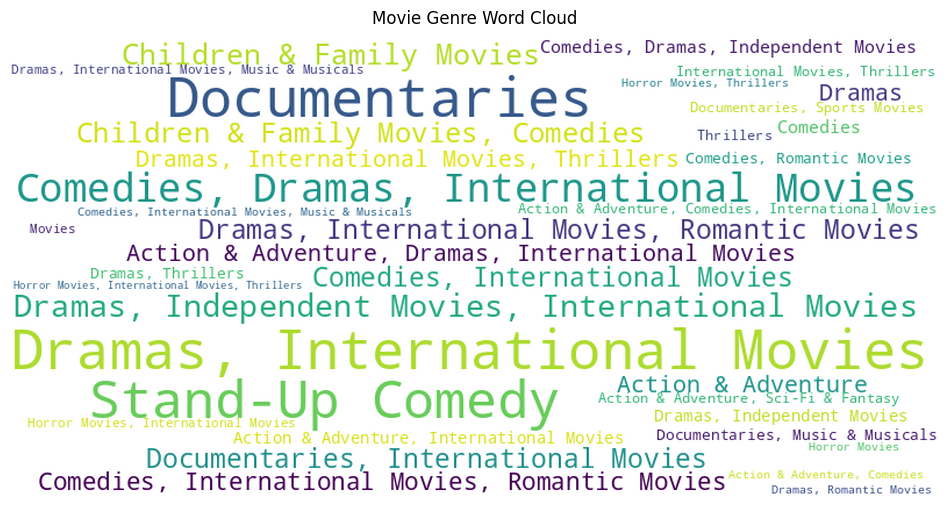

In [225]:
from wordcloud import WordCloud

plt.figure(figsize=(12, 10))

movie_genre= data[data['type'] == 'Movie'].groupby("listed_in")["show_id"].nunique().sort_values(ascending=False)
text_m= ' '.join(movie_genre.index)

wordcloud_m= WordCloud(width=800, height=400, background_color='white', colormap= 'viridis', prefer_horizontal=1.0, min_font_size=8).generate_from_frequencies(movie_genre.to_dict())

plt.imshow(wordcloud_m, interpolation='spline36')
plt.axis('off')
plt.title('Movie Genre Word Cloud')
plt.show()

**Popular Genre In TV Shows**

In [226]:
data[data['type'] == 'TV Show'].groupby("listed_in")["show_id"].nunique().sort_values (ascending=False).head() #data

listed_in
Kids' TV                                             220
International TV Shows, TV Dramas                    121
Crime TV Shows, International TV Shows, TV Dramas    110
Kids' TV, TV Comedies                                 99
Reality TV                                            95
Name: show_id, dtype: int64

In [227]:
data_unnested[data_unnested['type'] == 'TV Show'].groupby("listed_in")["show_id"].nunique().sort_values (ascending=False).head(10) #data_unnested

listed_in
International TV Shows    1351
TV Dramas                  763
TV Comedies                581
Crime TV Shows             470
Kids' TV                   451
Docuseries                 395
Romantic TV Shows          370
Reality TV                 255
British TV Shows           253
Anime Series               176
Name: show_id, dtype: int64

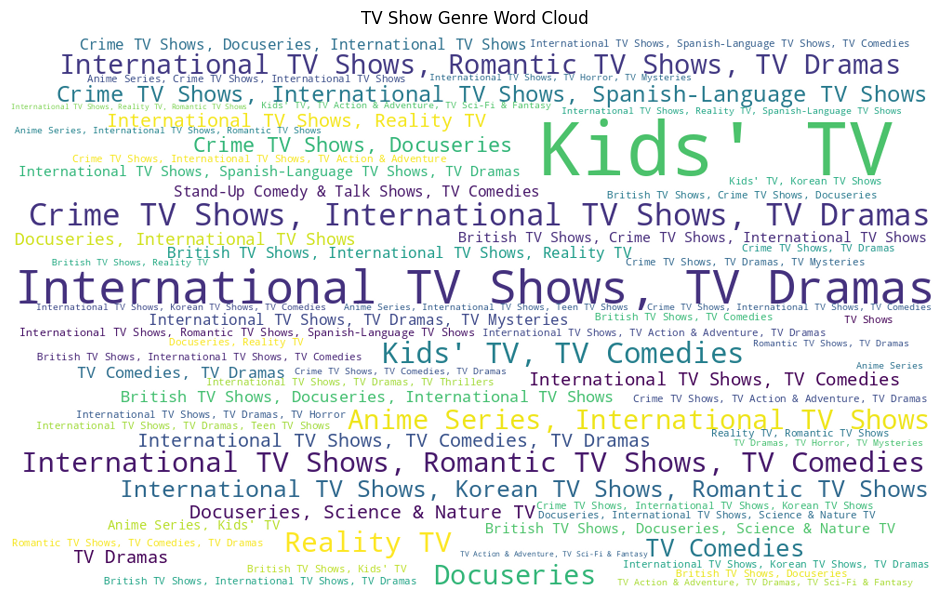

In [228]:
plt.figure(figsize=(12, 10))

tv_genre= data[data['type'] == 'TV Show'].groupby("listed_in")["show_id"].nunique().sort_values(ascending=False)
text_tv= ' '.join(tv_genre.index)

wordcloud_tv = WordCloud(width=1000, height=600, background_color='white', colormap= 'viridis', prefer_horizontal=1.0, min_font_size=8).generate_from_frequencies(tv_genre.to_dict())

plt.imshow(wordcloud_tv, interpolation='spline16')
plt.axis('off')
plt.title('TV Show Genre Word Cloud')
plt.show()

**Top 10 Genre- Movies Vs TV SHows**

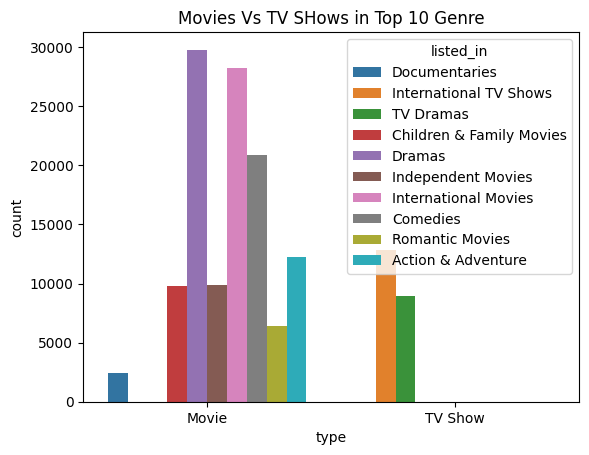

In [229]:
top10__genre= data_unnested.groupby('listed_in')['show_id'].nunique().sort_values(ascending= False).head(10).index
type_count= data['type'].value_counts().index
top_genre= data_unnested.loc[(data_unnested['listed_in'].isin(top10__genre)) & (data_unnested['type'].isin(type_count))]
sns.countplot(data= top_genre, x= 'type', hue= 'listed_in')
plt.title('Movies Vs TV SHows in Top 10 Genre')
plt.show()

**Insight And Recommendation**


**>Insights:**

*Genre Preferences: The data reveals that dramas and international movies are the most prevalent genres among movies, while TV dramas and international TV shows dominate among TV shows. This indicates a strong audience interest in compelling narratives and diverse cultural experiences across both movie and TV show formats.*

*Global Appeal: The popularity of dramas and international content underscores their universal appeal, transcending geographical boundaries and resonating with audiences worldwide. This suggests that Netflix can capitalize on these genres to cater to its diverse global subscriber base, fostering inclusivity and cultural exchange.*

*Genre Diversity: While dramas and international content are prominent, it's crucial for Netflix to maintain a diverse range of genres to cater to varied viewer preferences. Offering a balanced mix of genres such as comedies, thrillers, documentaries, etc., ensures that Netflix's content library appeals to a broad spectrum of audiences, enhancing viewer satisfaction and engagement.*

*Content Curation: Netflix should continue investing in acquiring and producing high-quality content within popular genres like dramas and TV dramas. By leveraging insights from viewer preferences and market trends, Netflix can curate compelling content that captivates audiences and differentiates itself from competitors.*

*Strategic Acquisitions: Understanding the popularity of specific genres can inform Netflix's content acquisition strategy. By strategically acquiring rights to sought-after genres and collaborating with renowned creators and studios, Netflix can enhance its content offering and solidify its position as a leading streaming platform in the competitive entertainment industry.*

**>Recommendations:**

*Diversify Content: While maintaining focus on popular genres, Netflix should also explore niche genres to cater to specialized audience interests and expand its content catalog.*

*Invest in Originals: Developing original content across various genres allows Netflix to differentiate itself and retain subscribers. Investing in original productions can also provide creative freedom and exclusive content unavailable elsewhere.*

*Personalization: Utilize data analytics and recommendation algorithms to personalize content recommendations for individual viewers based on their viewing history, preferences, and demographic information.*

*Global Expansion: Continuously assess and adapt content strategies to cater to diverse international markets. Investing in local content production and licensing agreements can strengthen Netflix's presence in global markets.*

*Engage with Creators: Foster relationships with talented creators, directors, and production studios to collaborate on innovative projects. Supporting diverse voices and storytelling perspectives can lead to fresh and compelling content offerings.*

# **6. Find After How Many Days The Content Will Be Added To Netflix After The Release Of The Content**

Find After how many days the movie will be added to Netflix after the release of
the movie (you can consider the recent past data)

Hint : We want you to get the difference between the columns having date added
information and release year information and get the mode of difference. This
will give an insight into what will be the better time to add in Netflix

In [230]:
data['release_year'] = pd.to_datetime(data['release_year'], format= '%Y') #Converting release_year To Datetime Datatype

In [231]:
data['days_needed_to_add']= data['date_added'] - data['release_year']
data[['title',	'director', 'date_added', 'release_year', 'days_needed_to_add']].head()

,title,director,date_added,release_year,days_needed_to_add
0,Dick Johnson Is Dead,Kirsten Johnson,2021-09-25,2020-01-01,633 days
1,Blood & Water,unknown_director,2021-09-24,2021-01-01,266 days
2,Ganglands,Julien Leclercq,2021-09-24,2021-01-01,266 days
3,Jailbirds New Orleans,unknown_director,2021-09-24,2021-01-01,266 days
4,Kota Factory,unknown_director,2021-09-24,2021-01-01,266 days


In [232]:
(data['date_added'] - data['release_year']).mode()

0   334 days
dtype: timedelta64[ns]

**Insight And Recommendation**

*>**Insight:** The analysis indicates that there is an average delay of approximately 334 days between the release of new content and its addition to the Netflix platform. This delay suggests that Netflix may have a strategic approach to adding content, possibly involving negotiations, licensing agreements, or content selection processes.*

*>**Recommendation:** To optimize content release strategies and reduce the time gap between release and availability on the platform, Netflix could consider streamlining its acquisition and licensing processes. This may involve establishing more efficient partnerships with content creators and distributors, leveraging data analytics to identify trending content early, and prioritizing the acquisition of high-demand titles. Additionally, exploring opportunities for exclusive or early access deals could help Netflix secure popular content faster, enhancing its competitive edge in the streaming market.*

# **THANK YOU**

# **-Netflix Case Study By: Nitish Vishwanath Hatapaki**